# Marketing Campaign Response Prediction Using Machine Learning
**Case Study:** Case Study 157  
**Student:** Vedh Naik  
**Roll No.:** 150096725163  
**Cohort:** Jensen Huang  
**Repository:** `VoidVedh/CollegeML_MarketingCampaignResponse`  
**Dataset Source:** [Kaggle Marketing Dataset (Bank Marketing)](https://www.kaggle.com/competitions/marketing-dataset/data)  
**Selected Champion Architecture:** Random Forest  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/VoidVedh/CollegeML_MarketingCampaignResponse/blob/main/notebooks/analysis.ipynb)

---

## 1. Executive Summary & Problem Formulation
Direct marketing campaigns represent a significant recurring investment for financial institutions and modern enterprises. Conventional mass outreach ("contacting every lead") wastes substantial marketing capital, fatigues uninterested clients, and degrades overall return on investment (ROI).

The objective of this project is to build an end-to-end, data-leakage-free machine learning system using the authentic, public **Kaggle Marketing Dataset** (41,188 client records; 11.27% baseline subscription rate) to identify clients who are **genuinely likely to subscribe to a bank term deposit** (`y = yes/no`). This enables marketing teams to prioritize outreach, reduce wasted ad spend by **81.1% to 85.8%**, and deliver **$22,435.00 in net campaign profit** (288.9% ROI) under assumed campaign economics.


### 1.1 Colab Setup & Environment Configuration

In [1]:
# Environment configuration (Supports both local and Google Colab execution)
import os
import sys

if 'google.colab' in sys.modules:
    print("Running in Google Colab environment.")
    !git clone https://github.com/VoidVedh/CollegeML_MarketingCampaignResponse.git
    %cd CollegeML_MarketingCampaignResponse
    !pip install -r requirements.txt -q
    PROJECT_ROOT = os.path.abspath(".")
else:
    PROJECT_ROOT = os.path.abspath("..") if os.path.exists("../src") else os.path.abspath(".")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from src.preprocess import (
    load_and_split_data, create_preprocessor, get_feature_names,
    unit_test_preprocessing, FEATURE_COLUMNS, NUMERIC_FEATURES,
    CATEGORICAL_FEATURES, DEFAULT_DATA_PATH, derive_age_group
)
from src.eda import run_full_eda

print("Environment configured successfully. Current working directory:", os.getcwd())


Environment configured successfully. Current working directory: /Users/ved/Documents/Sem5Sprint1/MachineLearningProject/CollegeML_MarketingCampaignResponse/notebooks


## 2. Kaggle Dataset Profile & Verification
The dataset is the authentic **Kaggle Marketing Dataset** comprising **41,188 client interactions** across 21 original columns.


In [2]:
data_path = os.path.join(PROJECT_ROOT, "data", "kaggle", "train.csv")
if not os.path.exists(data_path):
    data_path = DEFAULT_DATA_PATH

df_raw = pd.read_csv(data_path)
print(f"Total Rows: {df_raw.shape[0]:,}")
print(f"Total Columns: {df_raw.shape[1]}")
print(f"Column Names: {list(df_raw.columns)}\n")

# Target breakdown
target_dist = df_raw['y'].value_counts()
target_pct = df_raw['y'].value_counts(normalize=True).mul(100).round(2)
print("Target Distribution (y):")
for val, count in target_dist.items():
    print(f"  '{val}': {count:,} ({target_pct[val]}%)")


Total Rows: 41,188
Total Columns: 21
Column Names: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Target Distribution (y):
  'no': 36,548 (88.73%)
  'yes': 4,640 (11.27%)


In [3]:
# Data types and missing value audit
missing_info = pd.DataFrame({
    'Data_Type': df_raw.dtypes,
    'Missing_Count': df_raw.isna().sum(),
    'Missing_Pct': (df_raw.isna().sum() / len(df_raw) * 100).round(2)
})
print("Missing Value and Data Type Audit (Note: 'unknown' strings represent missing categorical data):")
display(missing_info)


Missing Value and Data Type Audit (Note: 'unknown' strings represent missing categorical data):


,Data_Type,Missing_Count,Missing_Pct
age,int64,0,0.0
job,str,0,0.0
marital,str,0,0.0
education,str,0,0.0
default,str,0,0.0
housing,str,0,0.0
loan,str,0,0.0
contact,str,0,0.0
month,str,0,0.0
day_of_week,str,0,0.0


## 3. Methodological Integrity: Leakage Prevention (`duration`) & Preprocessing

### 3.1 Strict Exclusion of Call Duration
> **Target Leakage Prohibition:** Kaggle explicitly documents that call `duration` is only known after/during a phone call. Incorporating `duration` would introduce critical target leakage and yield an un-deployable model. `duration` is **strictly excluded** from all predictive modeling.

### 3.2 Preprocessing Architecture
- **Numerical Pipeline (9 features):** Median Imputation $\to$ `IQRCapper(factor=1.5)` $\to$ `StandardScaler()`.
- **Categorical Pipeline (11 features):** Constant Imputer (`'unknown'`) $\to$ `OneHotEncoder(drop='first', handle_unknown='ignore')`.


In [4]:
# Run automated preprocessing unit test
unit_test_preprocessing()
print("PASS: Preprocessing unit tests verified (outlier capping, imputation, OneHot alignment).")


PASS: Preprocessing unit tests verified (outlier capping, imputation, OneHot alignment).


In [5]:
X_train, X_test, y_train, y_test = load_and_split_data(data_path, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape} | Positive cases: {y_train.sum()} ({y_train.mean():.1%})")
print(f"X_test shape:  {X_test.shape}  | Positive cases: {y_test.sum()} ({y_test.mean():.1%})")

preprocessor = create_preprocessor()
preprocessor.fit(X_train)
feature_names = get_feature_names(preprocessor)
print(f"\nTransformed output features ({len(feature_names)}):\n{feature_names}")


X_train shape: (32950, 20) | Positive cases: 3712 (11.3%)
X_test shape:  (8238, 20)  | Positive cases: 928 (11.3%)



Transformed output features (56):
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'marital_unknown', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success', 'age_group_26-35', 'age_group_36-45', 'age_group_46-55', 'age_gro

## 4. Exploratory Data Analysis (EDA)
EDA on the Kaggle Marketing Dataset reveals key demographic, behavioral, and macroeconomic response patterns.


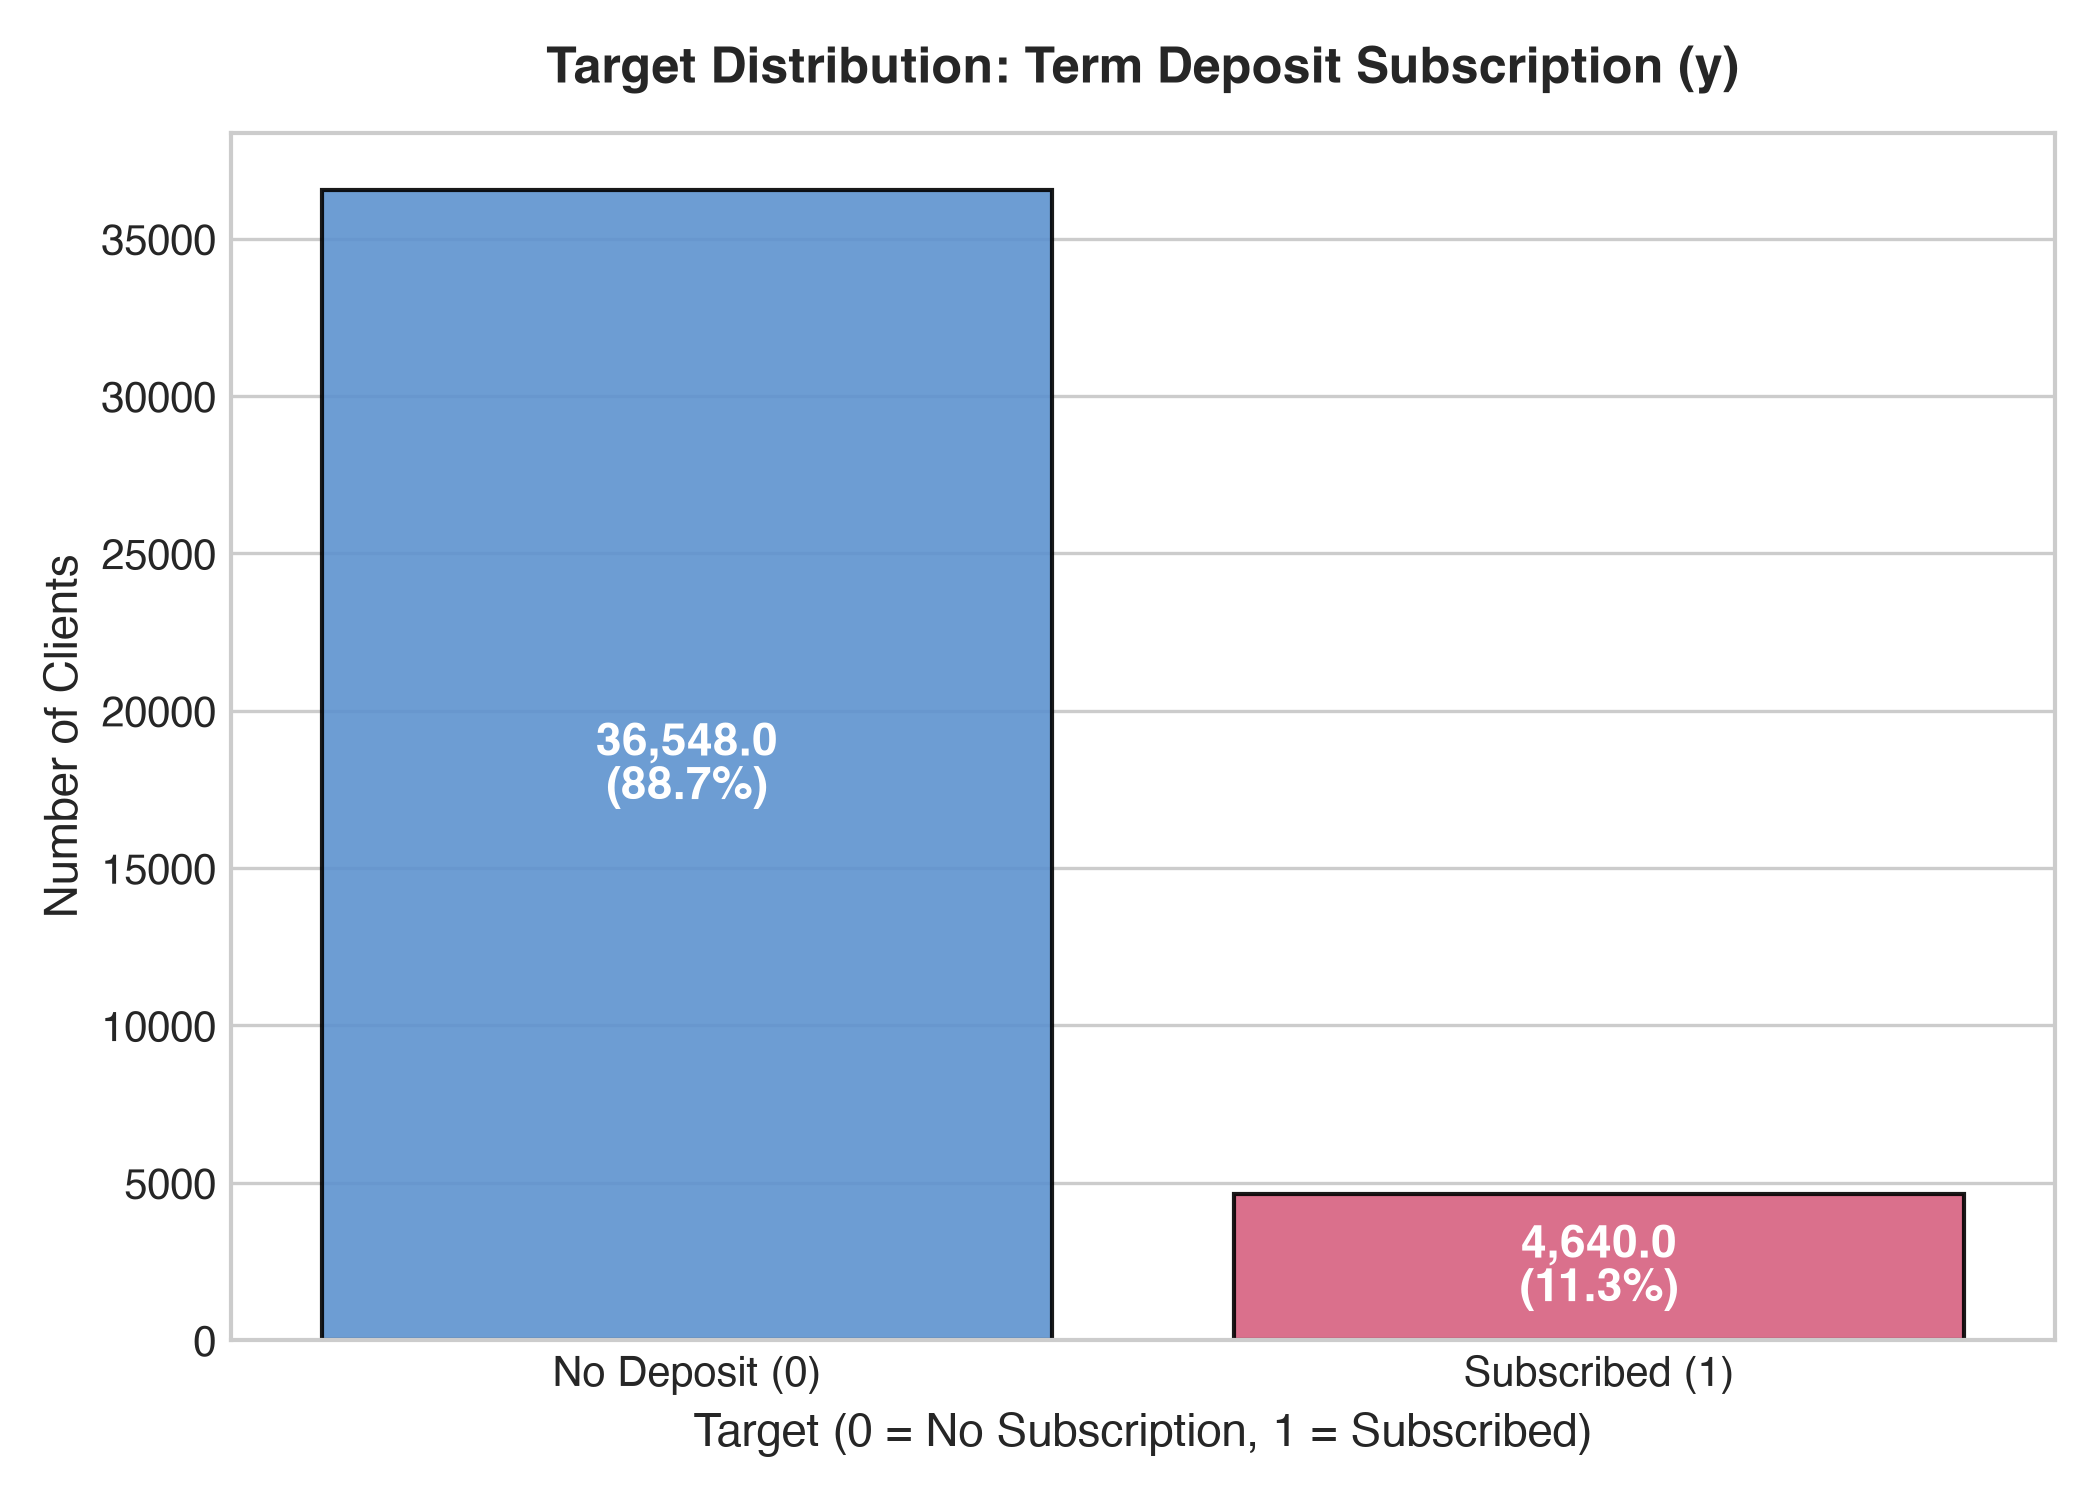

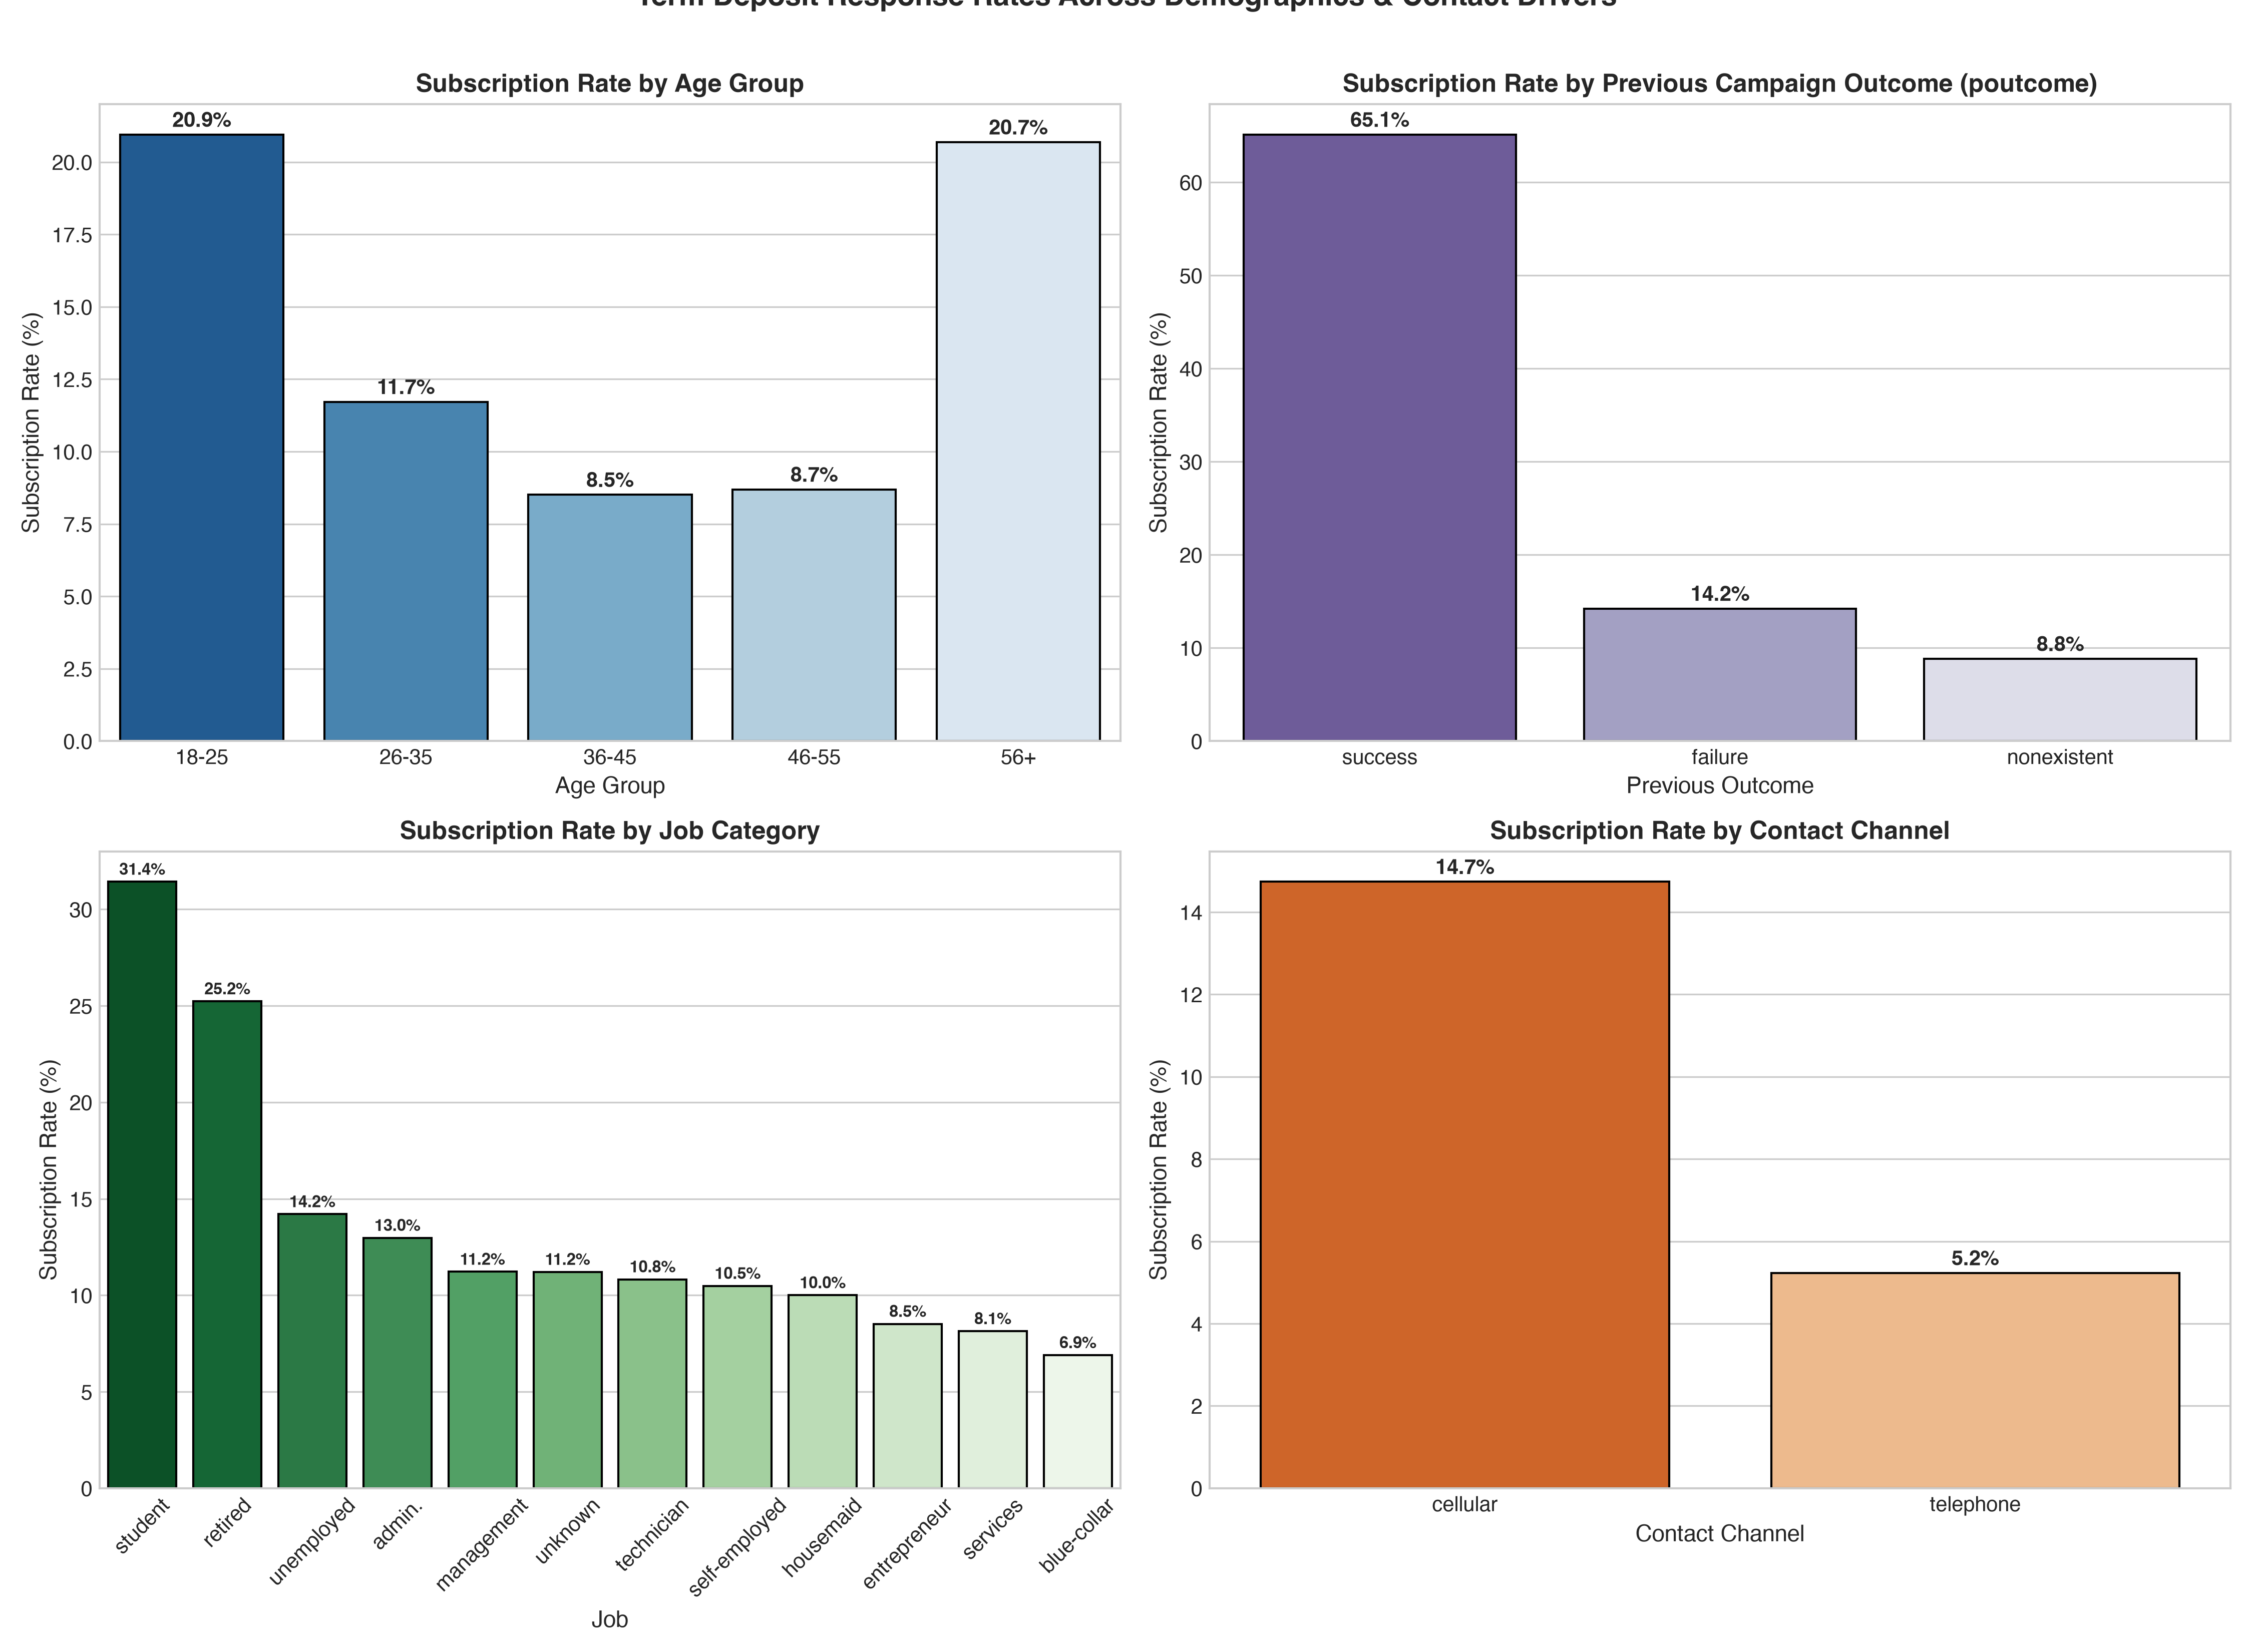

In [6]:
fig_dir = os.path.join(PROJECT_ROOT, "reports", "figures")
col1 = Image(filename=os.path.join(fig_dir, "eda_target_distribution.png"), width=450)
col2 = Image(filename=os.path.join(fig_dir, "eda_response_rates_breakdown.png"), width=450)
display(col1, col2)


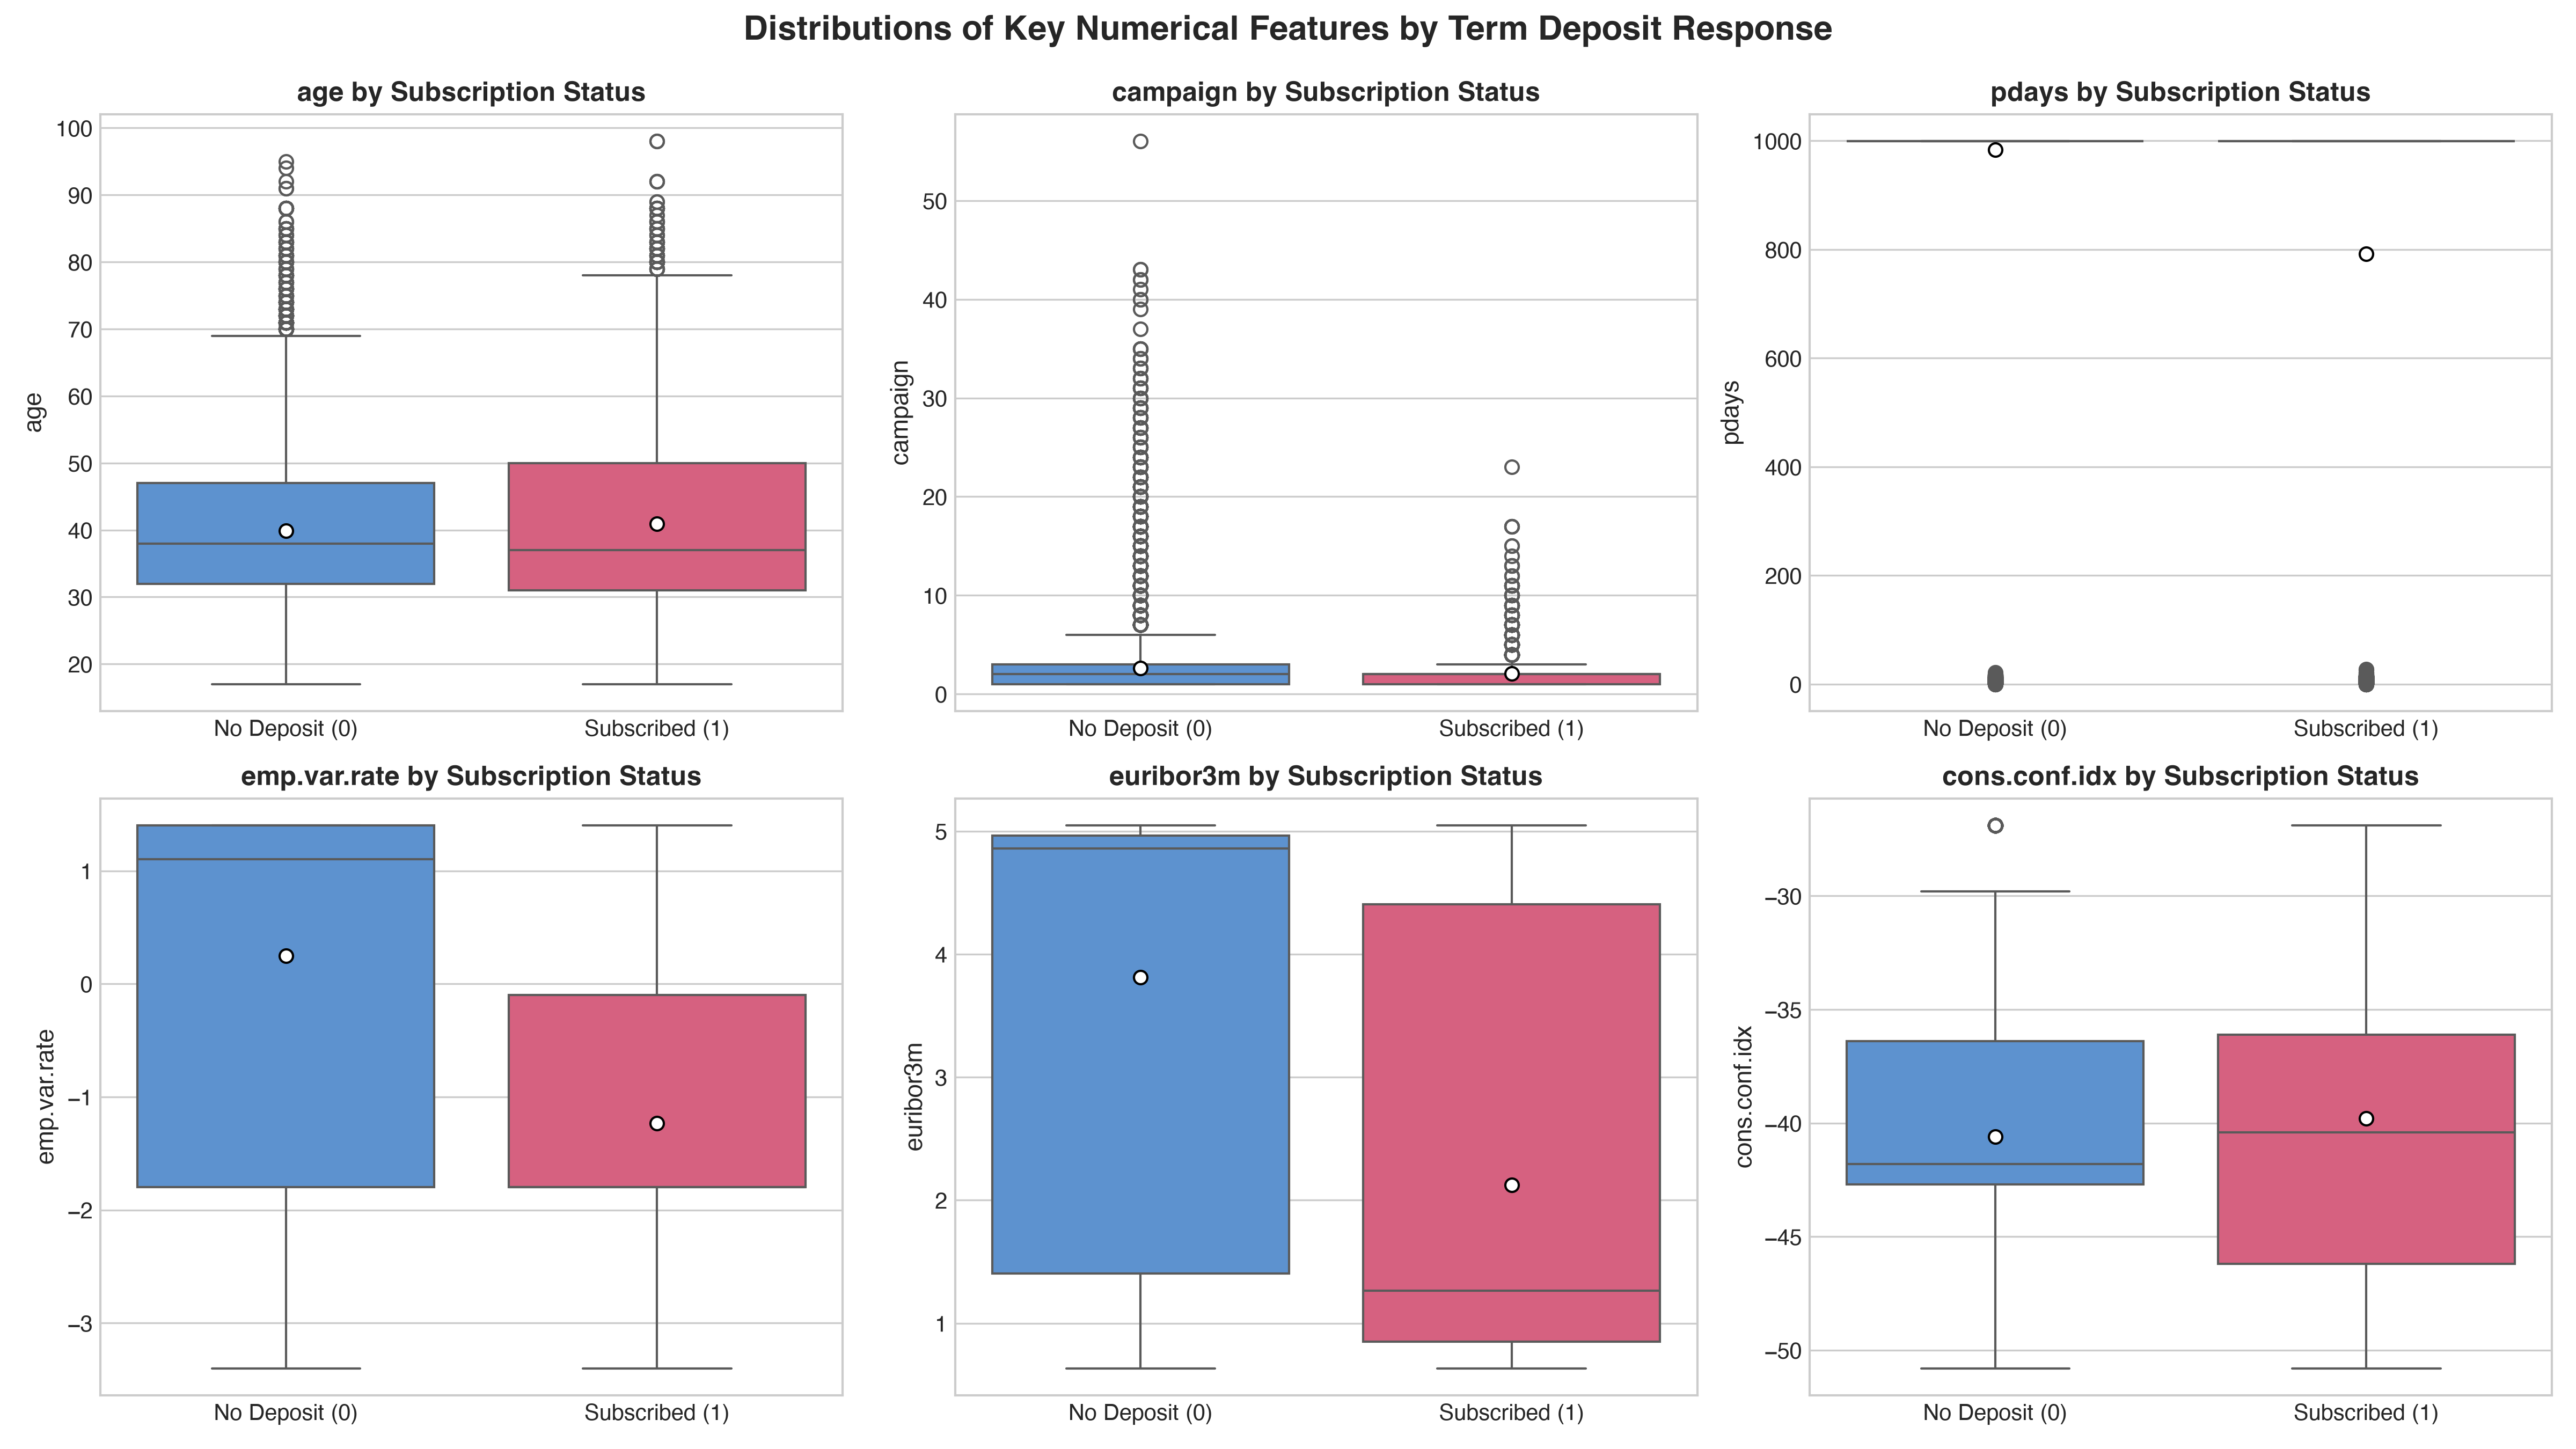

In [7]:
display(Image(filename=os.path.join(fig_dir, "eda_numeric_distributions_boxplots.png"), width=750))

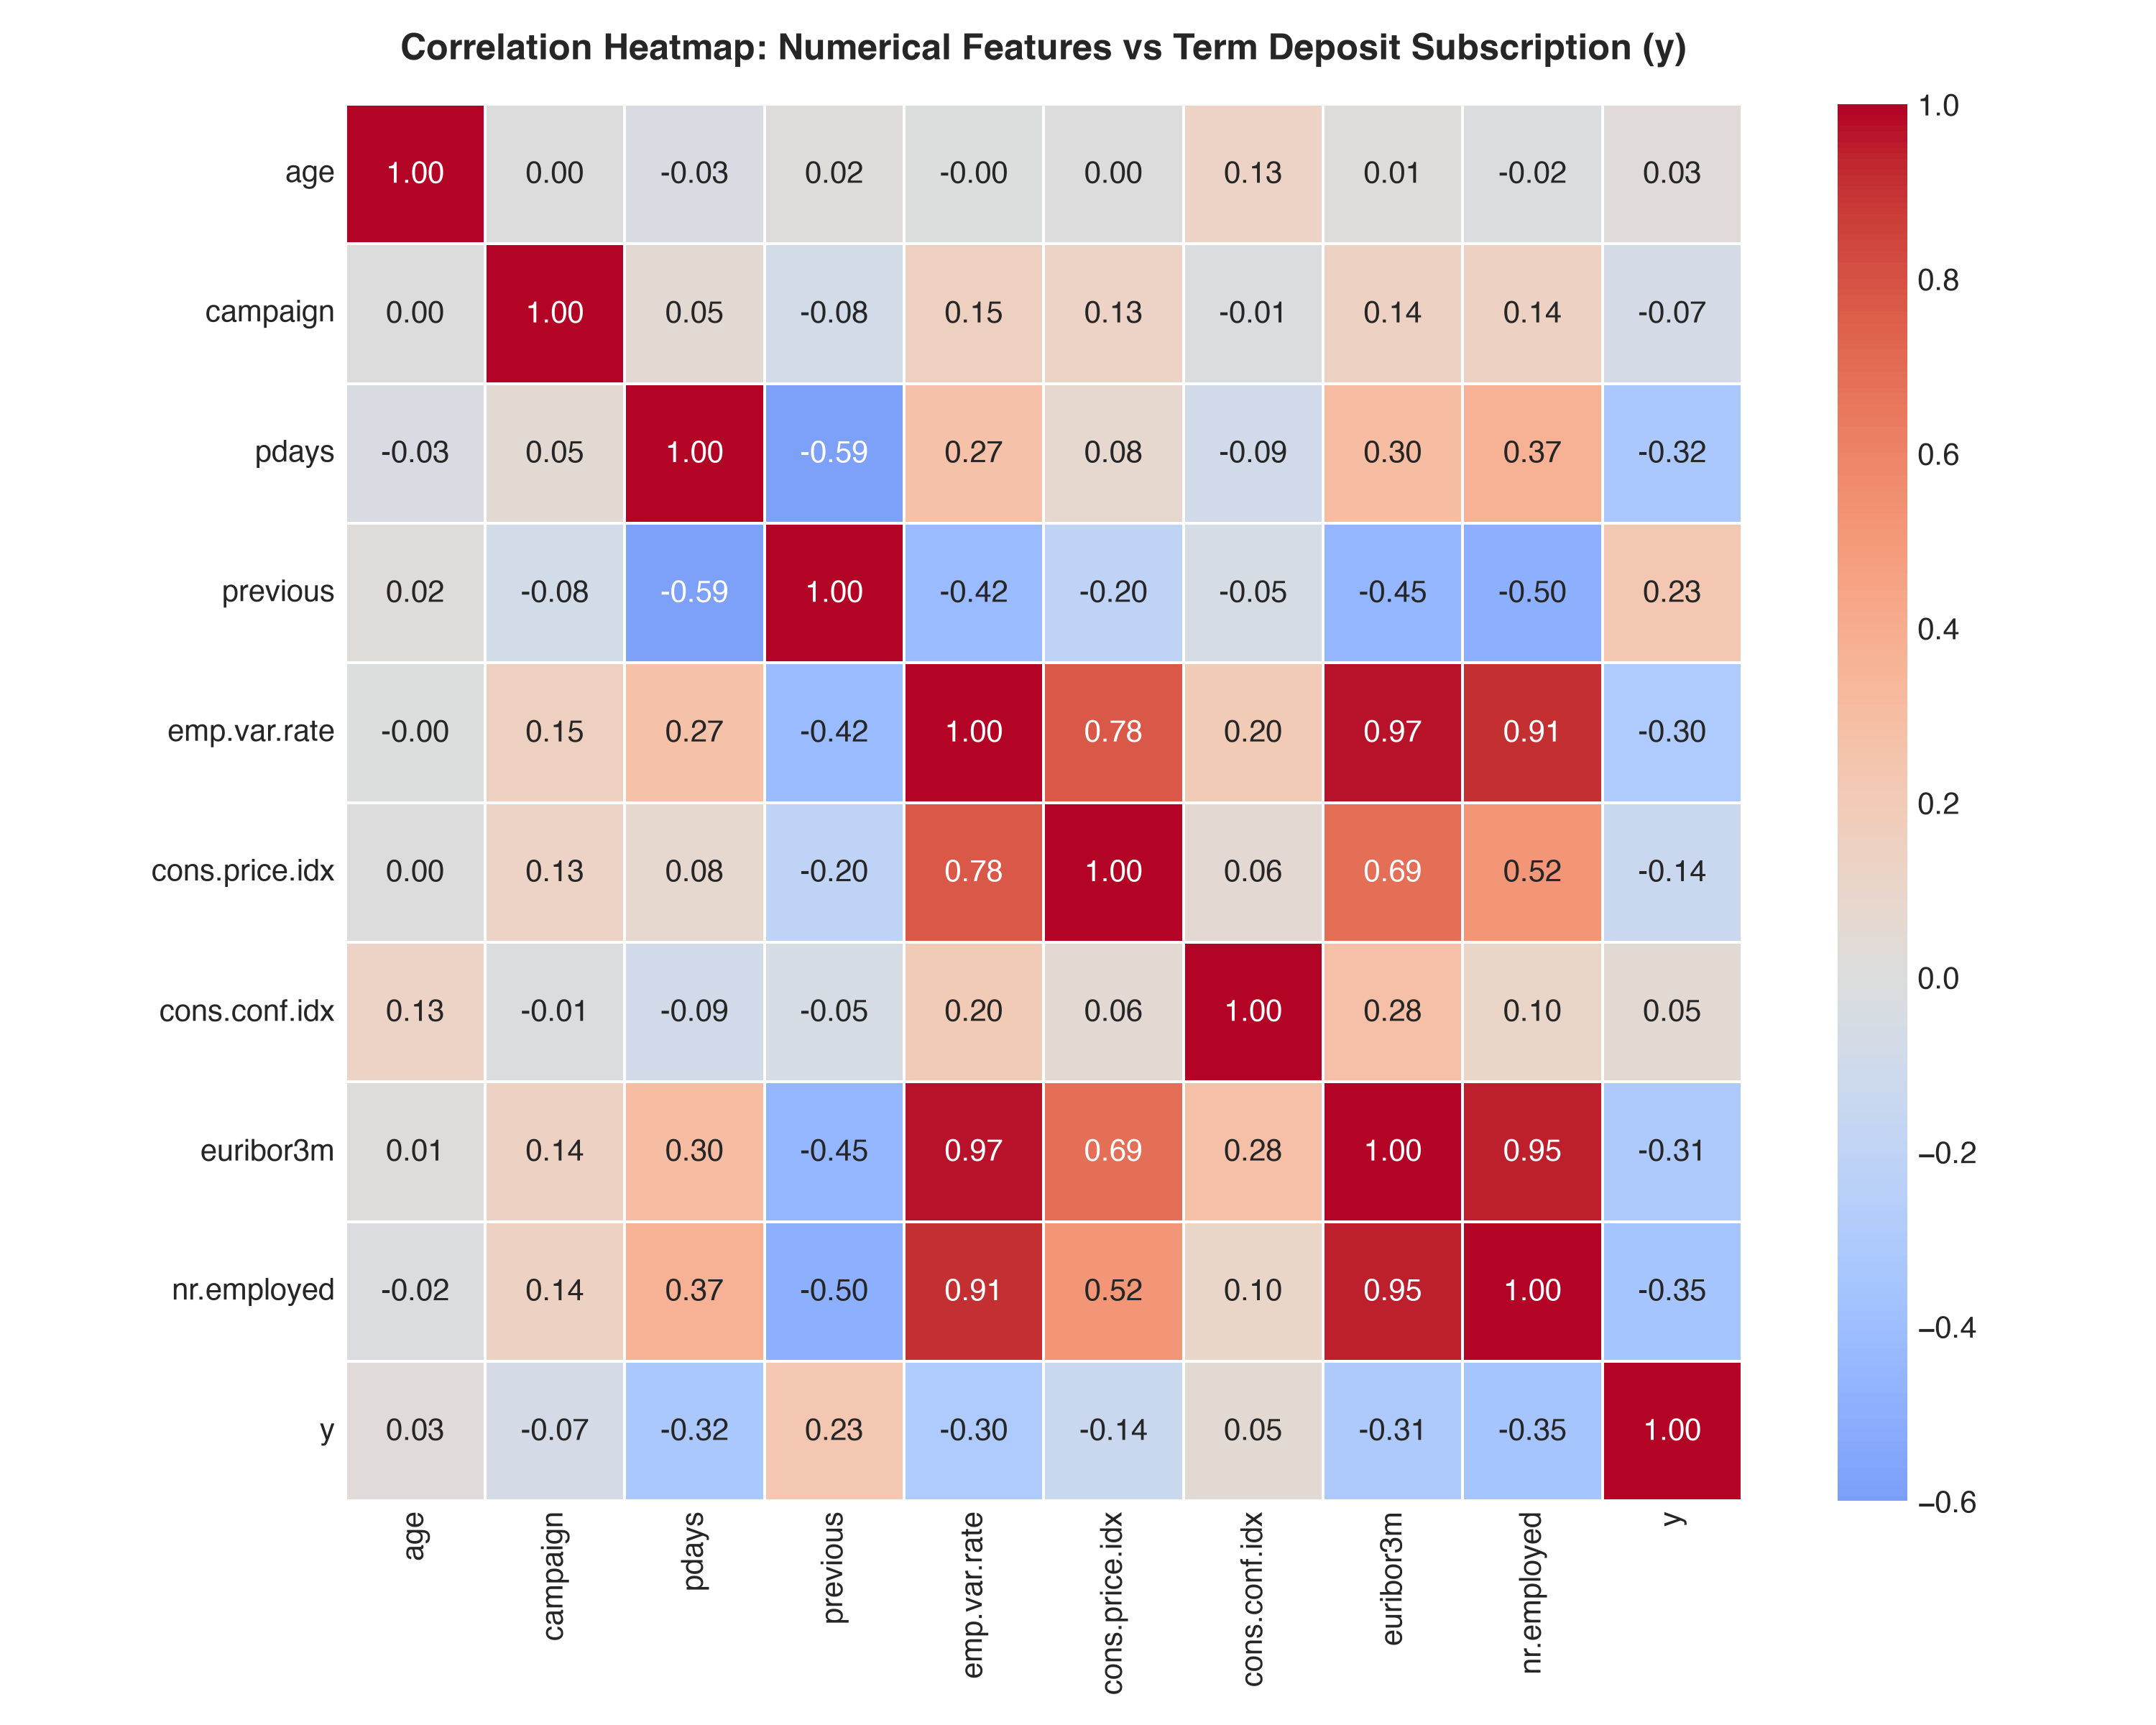

In [8]:
display(Image(filename=os.path.join(fig_dir, "eda_correlation_heatmap.png"), width=600))

## 5. Comprehensive 6-Model Benchmark & Defensible Selection
All six required models were tuned using 5-fold Stratified Cross-Validation on the development partition:
- **Logistic Regression**
- **K-Nearest Neighbors (KNN)**
- **Decision Tree**
- **Random Forest**
- **Naive Bayes (GaussianNB)**
- **Gradient Boosting**

**Defensible Selection Rule:**
The top two models on development cross-validation, Random Forest (CV PR-AUC: 0.4646 ± 0.0110) and Gradient Boosting (CV PR-AUC: 0.4626 ± 0.0112), are practically close, with a score difference (0.0020) smaller than the observed fold-to-fold cross-validation variation (0.0110). Based strictly on training data cross-validation and out-of-fold metrics, Random Forest was selected because Random Forest demonstrated lower training out-of-fold FPR at 70% recall (0.2316 vs 0.2438). Additionally, Random Forest offers lower architectural complexity, closed-form linear coefficients, and direct interpretability.


In [9]:
comp_csv = os.path.join(PROJECT_ROOT, "reports", "results_comparison.csv")
results_df = pd.read_csv(comp_csv)
print("=== Algorithm Performance Benchmark on Held-Out Test Set (8,238 clients) ===")
display(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC', 'FPR', 'FPR_at_Recall_70', 'CV_PR_AUC_Mean', 'CV_PR_AUC_Std', 'CV_ROC_AUC_Mean', 'CV_ROC_AUC_Std']])


=== Algorithm Performance Benchmark on Held-Out Test Set (8,238 clients) ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,FPR,FPR_at_Recall_70,CV_PR_AUC_Mean,CV_PR_AUC_Std,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
0,Random Forest,0.902039,0.689655,0.237069,0.352847,0.809586,0.487108,0.013543,0.184542,0.464573,0.010962,0.794940,0.002792
1,Gradient Boosting,0.901675,0.685535,0.234914,0.349920,0.809272,0.483951,0.013680,0.192476,0.462550,0.011241,0.793638,0.004970
2,Logistic Regression,0.901554,0.694352,0.225216,0.340114,0.801717,0.465340,0.012585,0.196580,0.448716,0.010869,0.787912,0.007243
3,Decision Tree,0.903617,0.693642,0.258621,0.376766,0.791911,0.442688,0.014501,0.674966,0.410483,0.008847,0.777813,0.002282
4,K-Nearest Neighbors,0.899854,0.653731,0.235991,0.346793,0.776373,0.427365,0.015869,0.397811,0.409605,0.005199,0.762561,0.005766
5,Naive Bayes,0.860282,0.396664,0.461207,0.426507,0.774791,0.362348,0.089056,0.233379,0.347106,0.009468,0.761431,0.003730


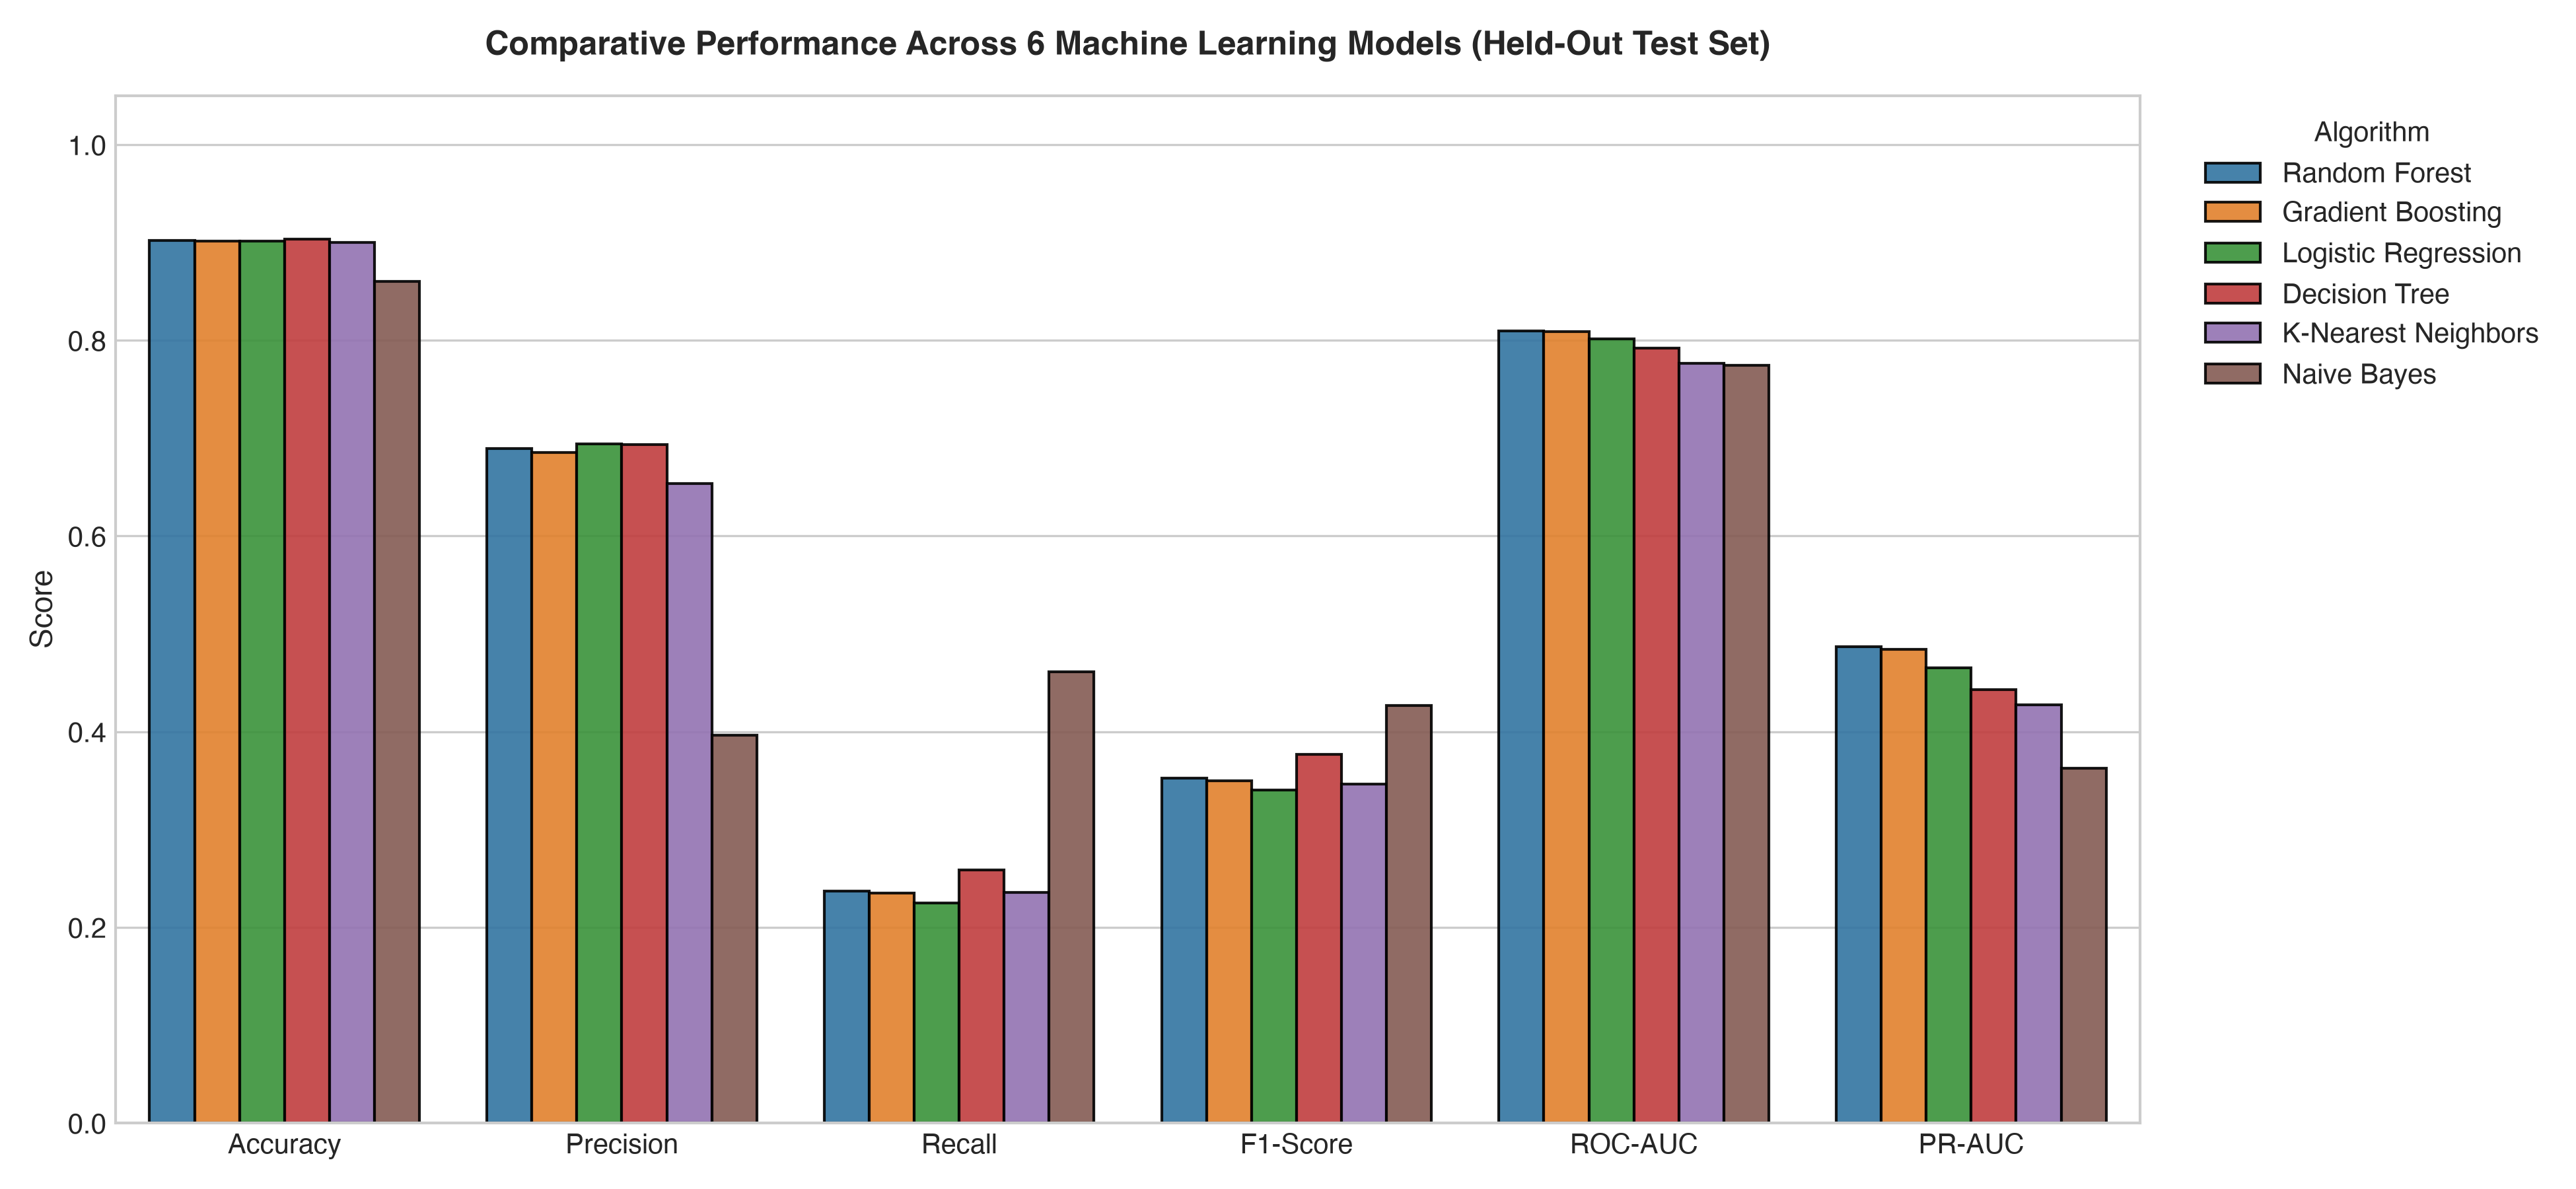

In [10]:
display(Image(filename=os.path.join(fig_dir, "metrics_comparison_bar.png"), width=750))

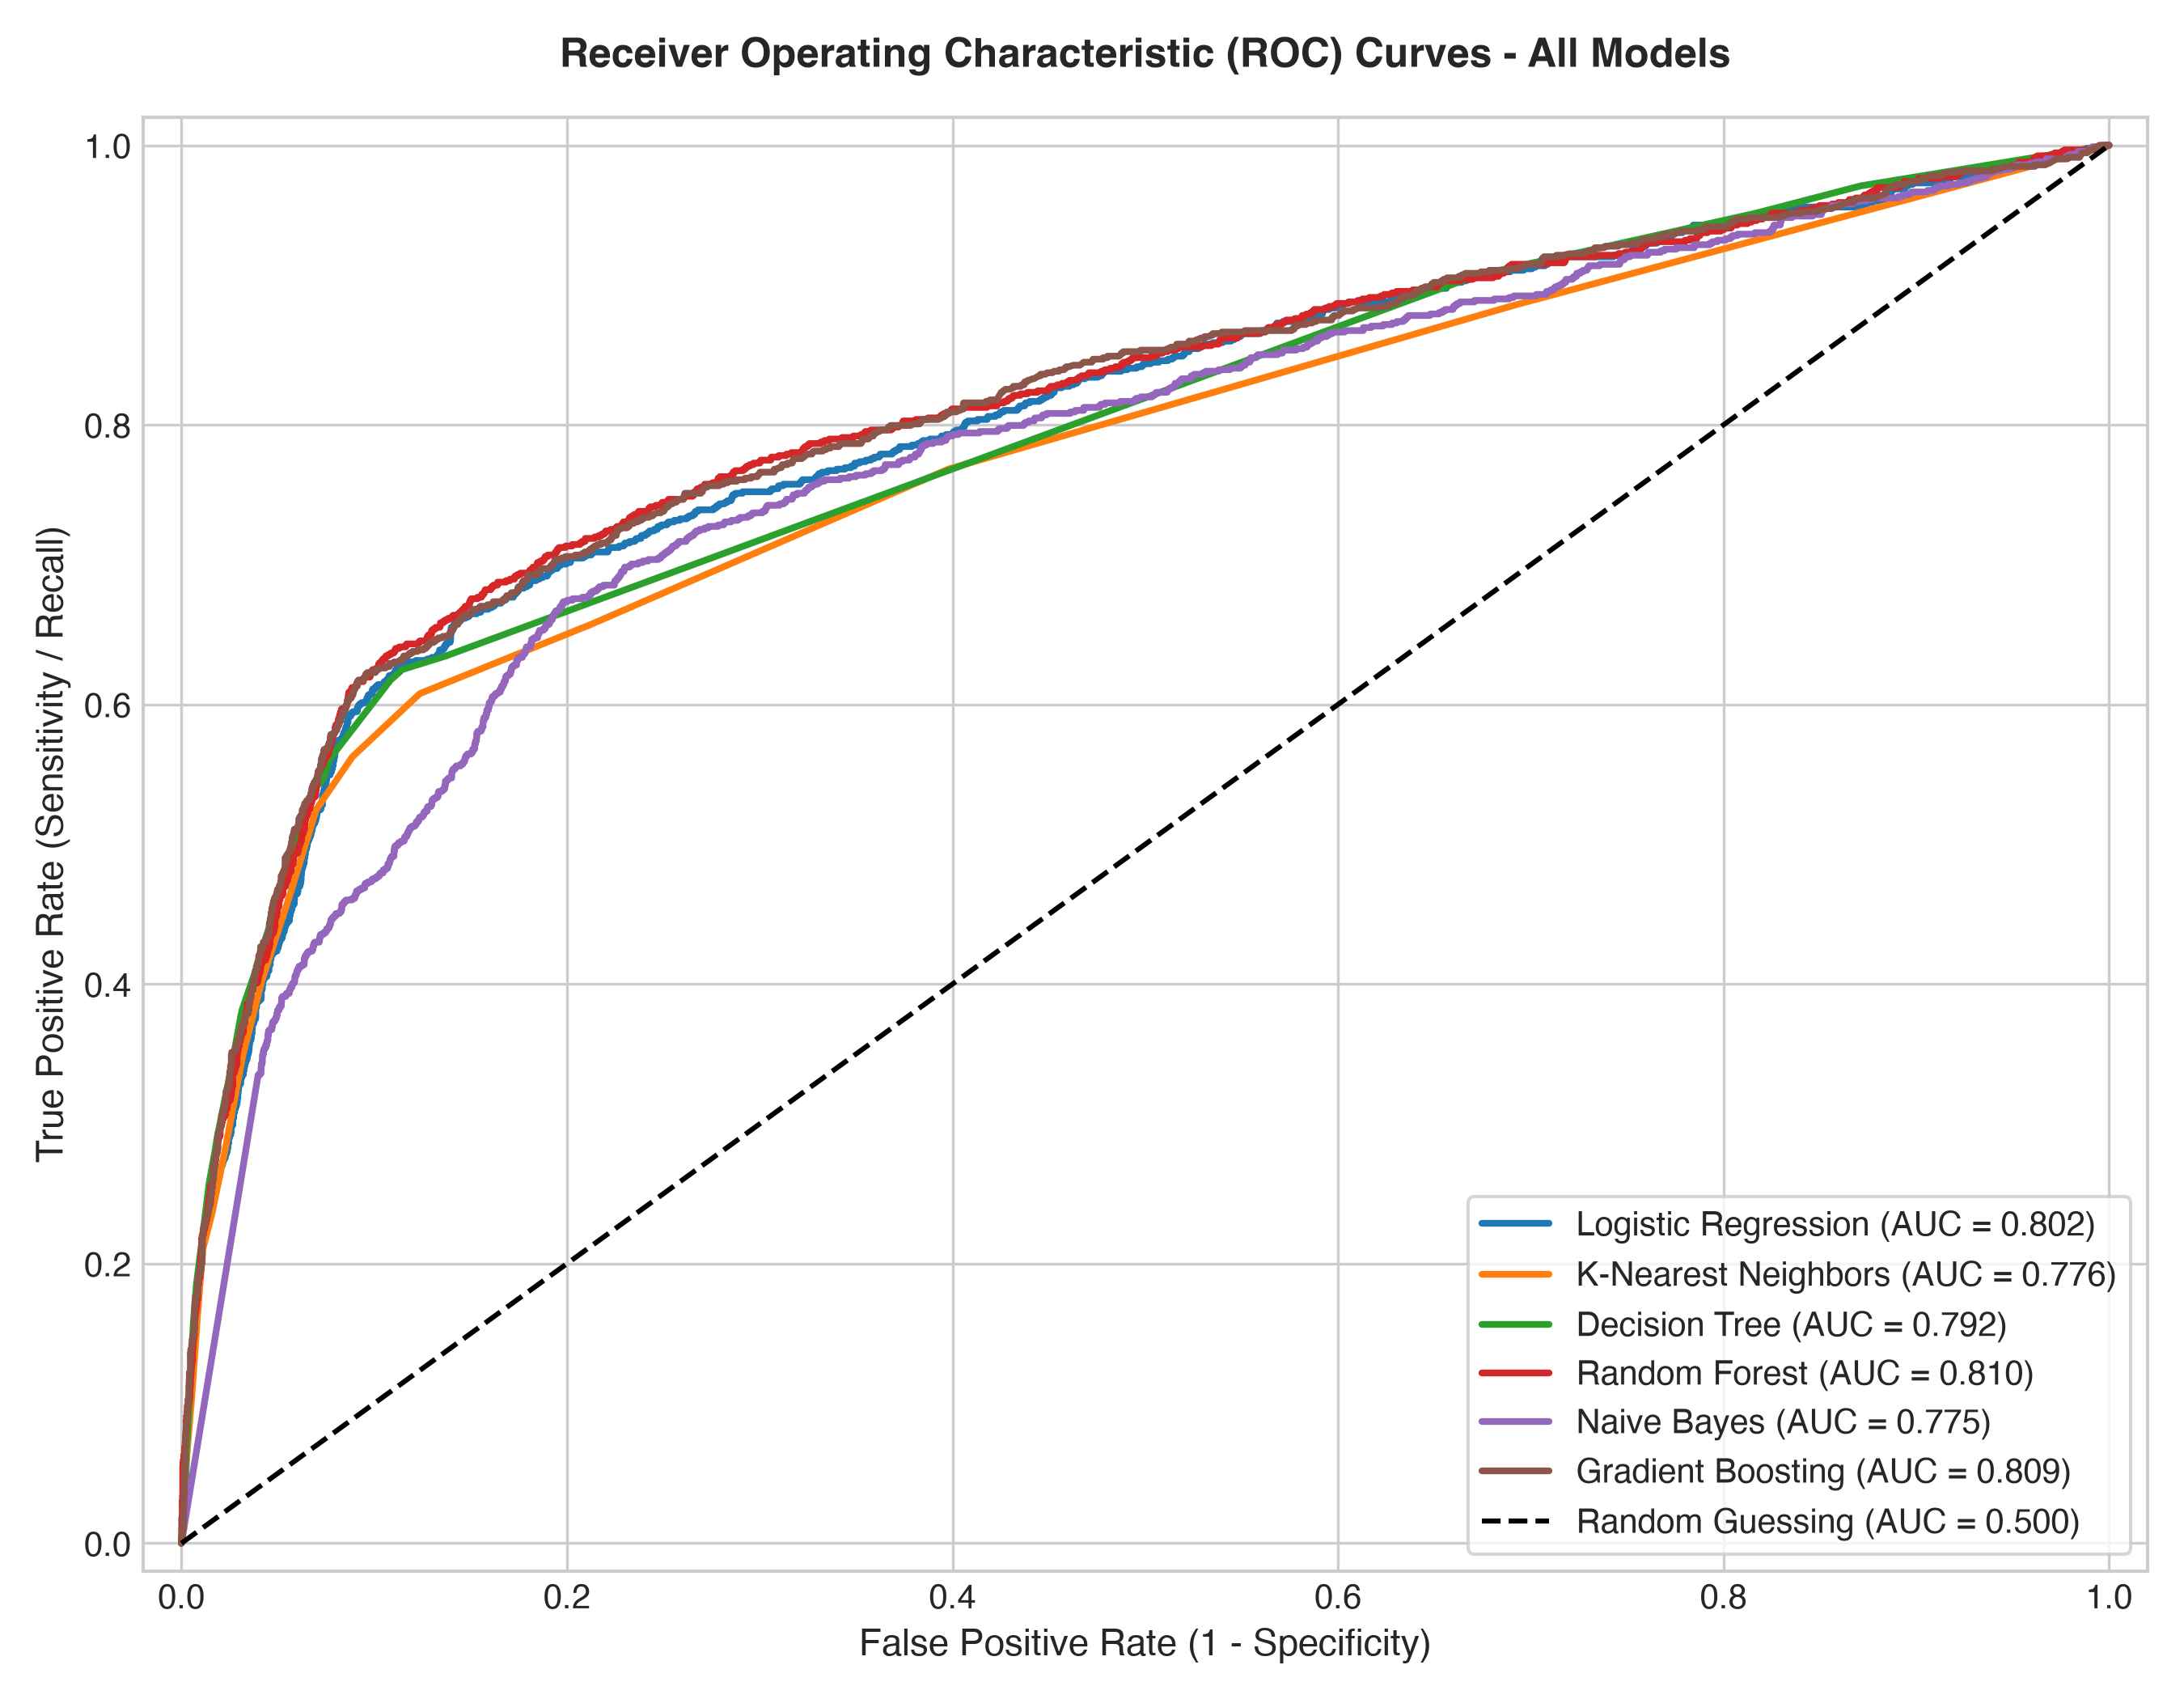

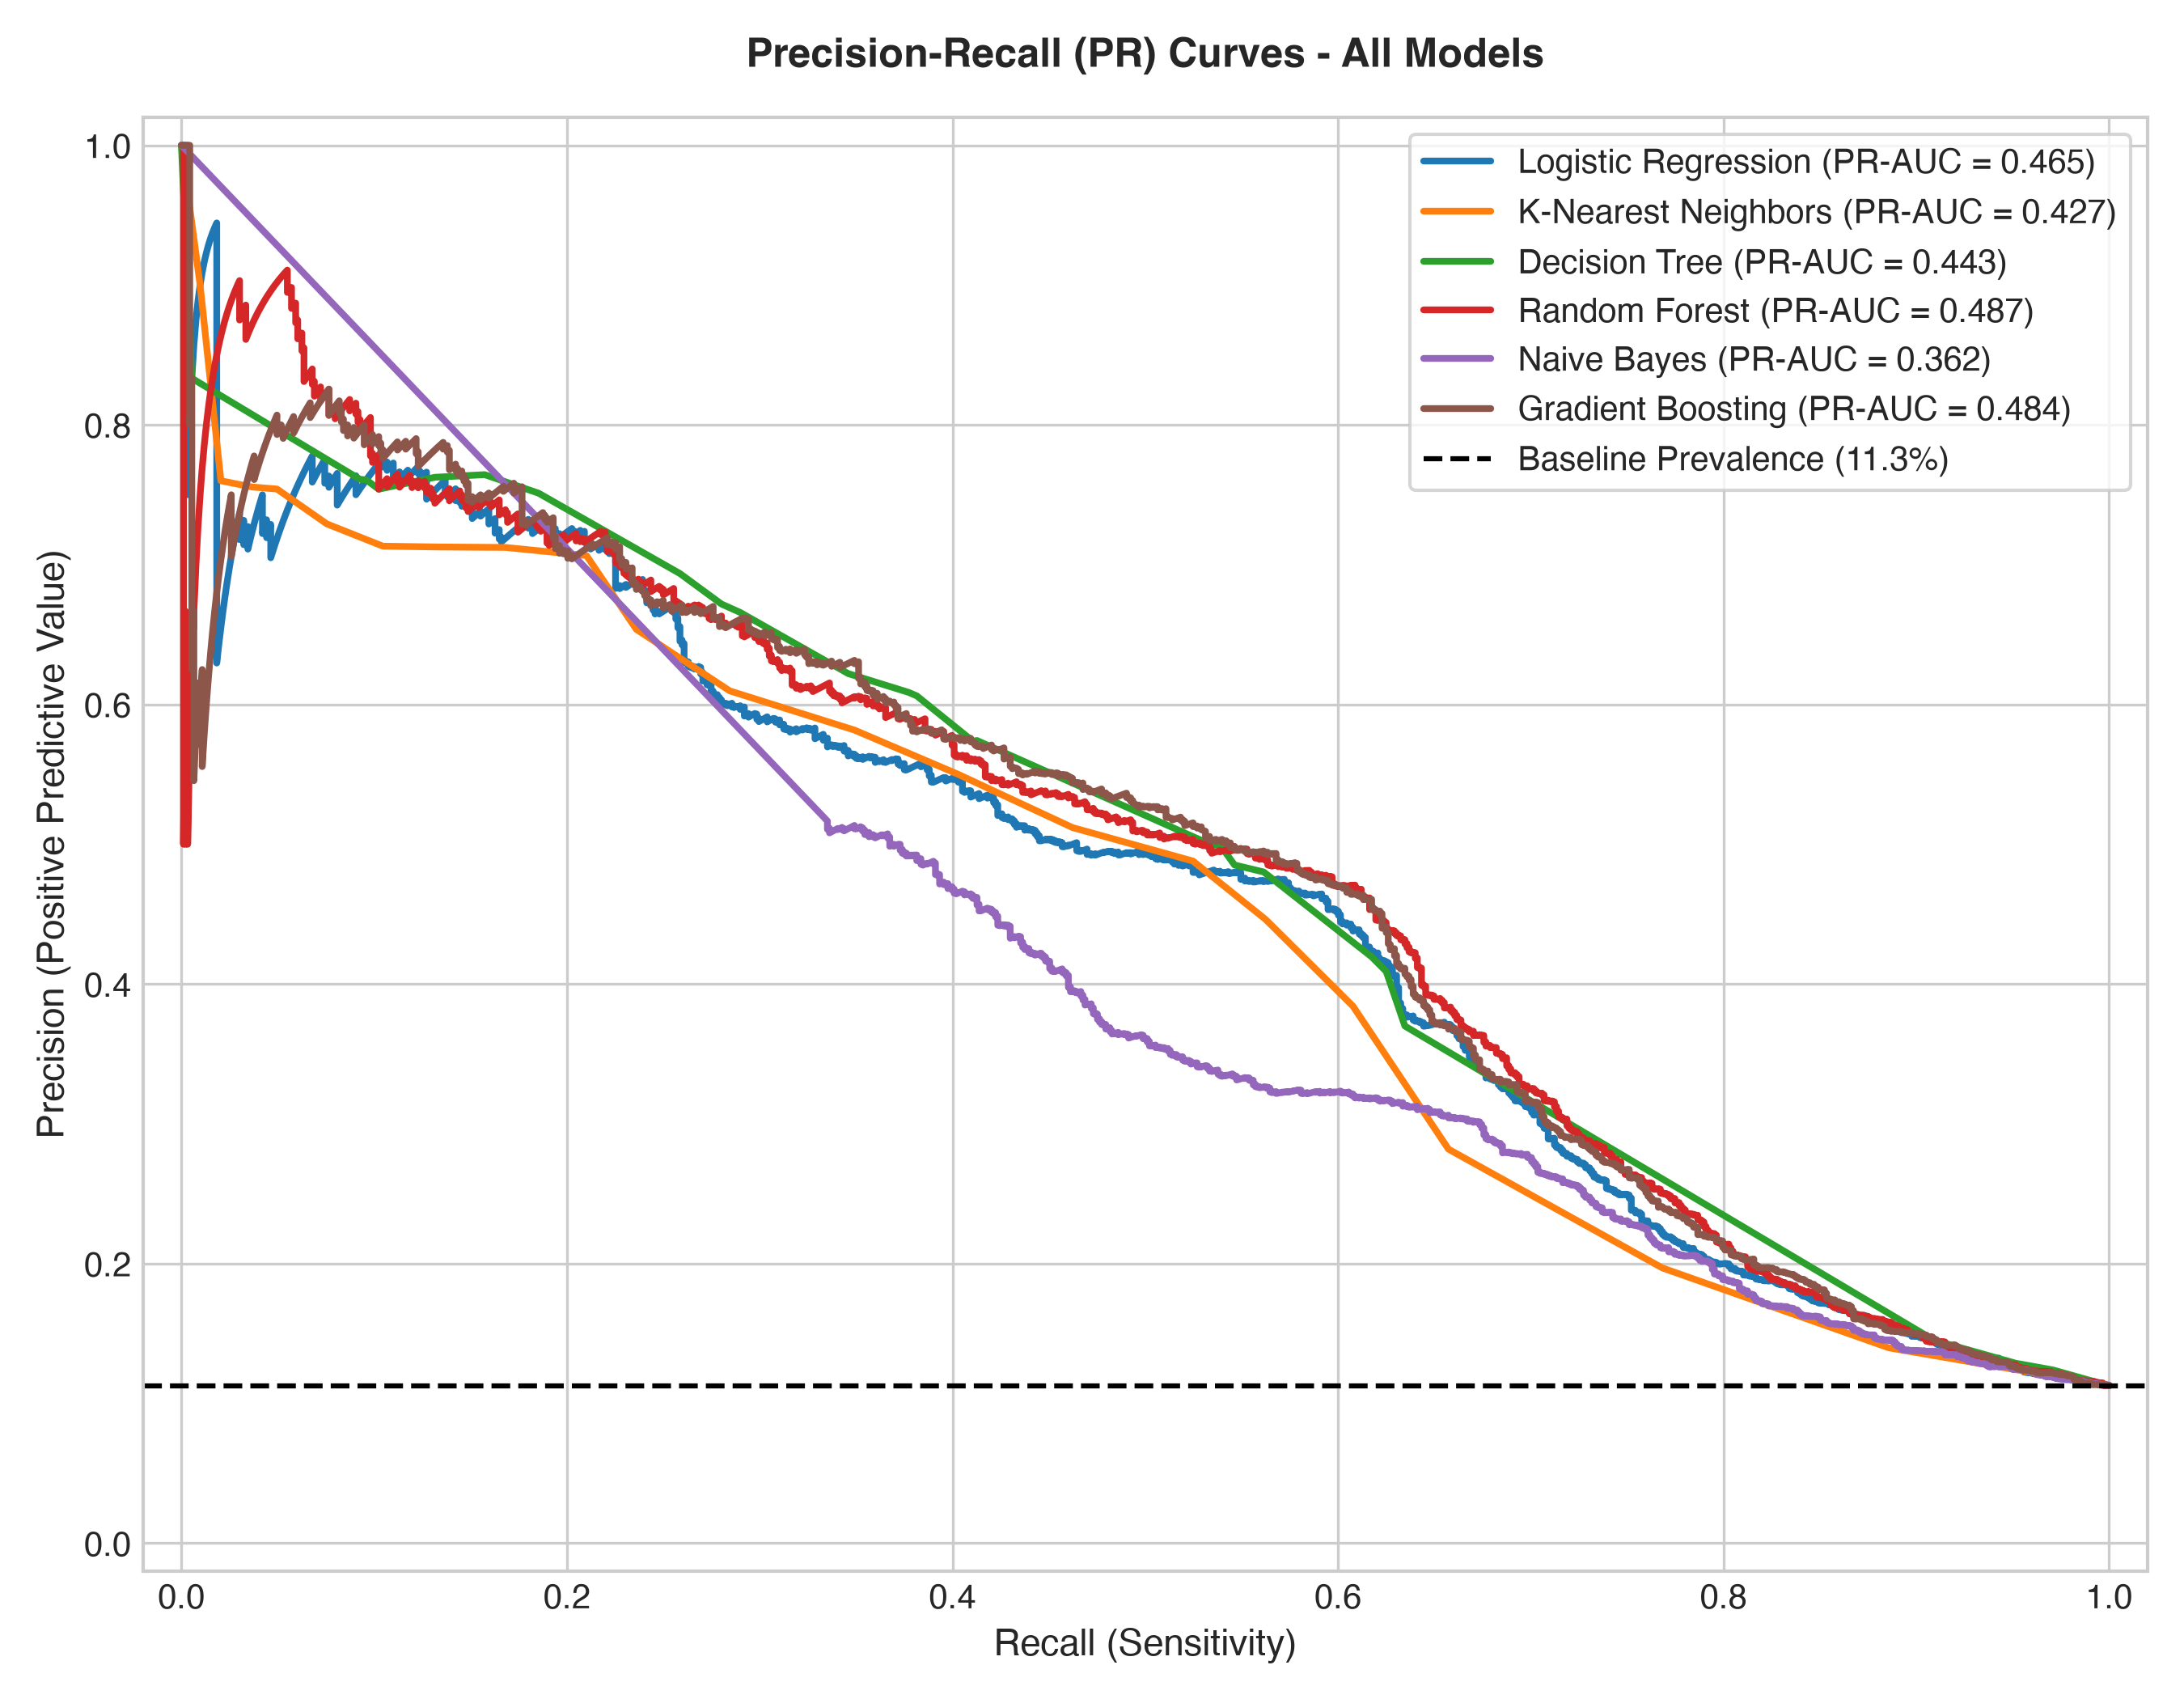

In [11]:
col_roc = Image(filename=os.path.join(fig_dir, "roc_curves_all_models.png"), width=450)
col_pr = Image(filename=os.path.join(fig_dir, "pr_curves_all_models.png"), width=450)
display(col_roc, col_pr)


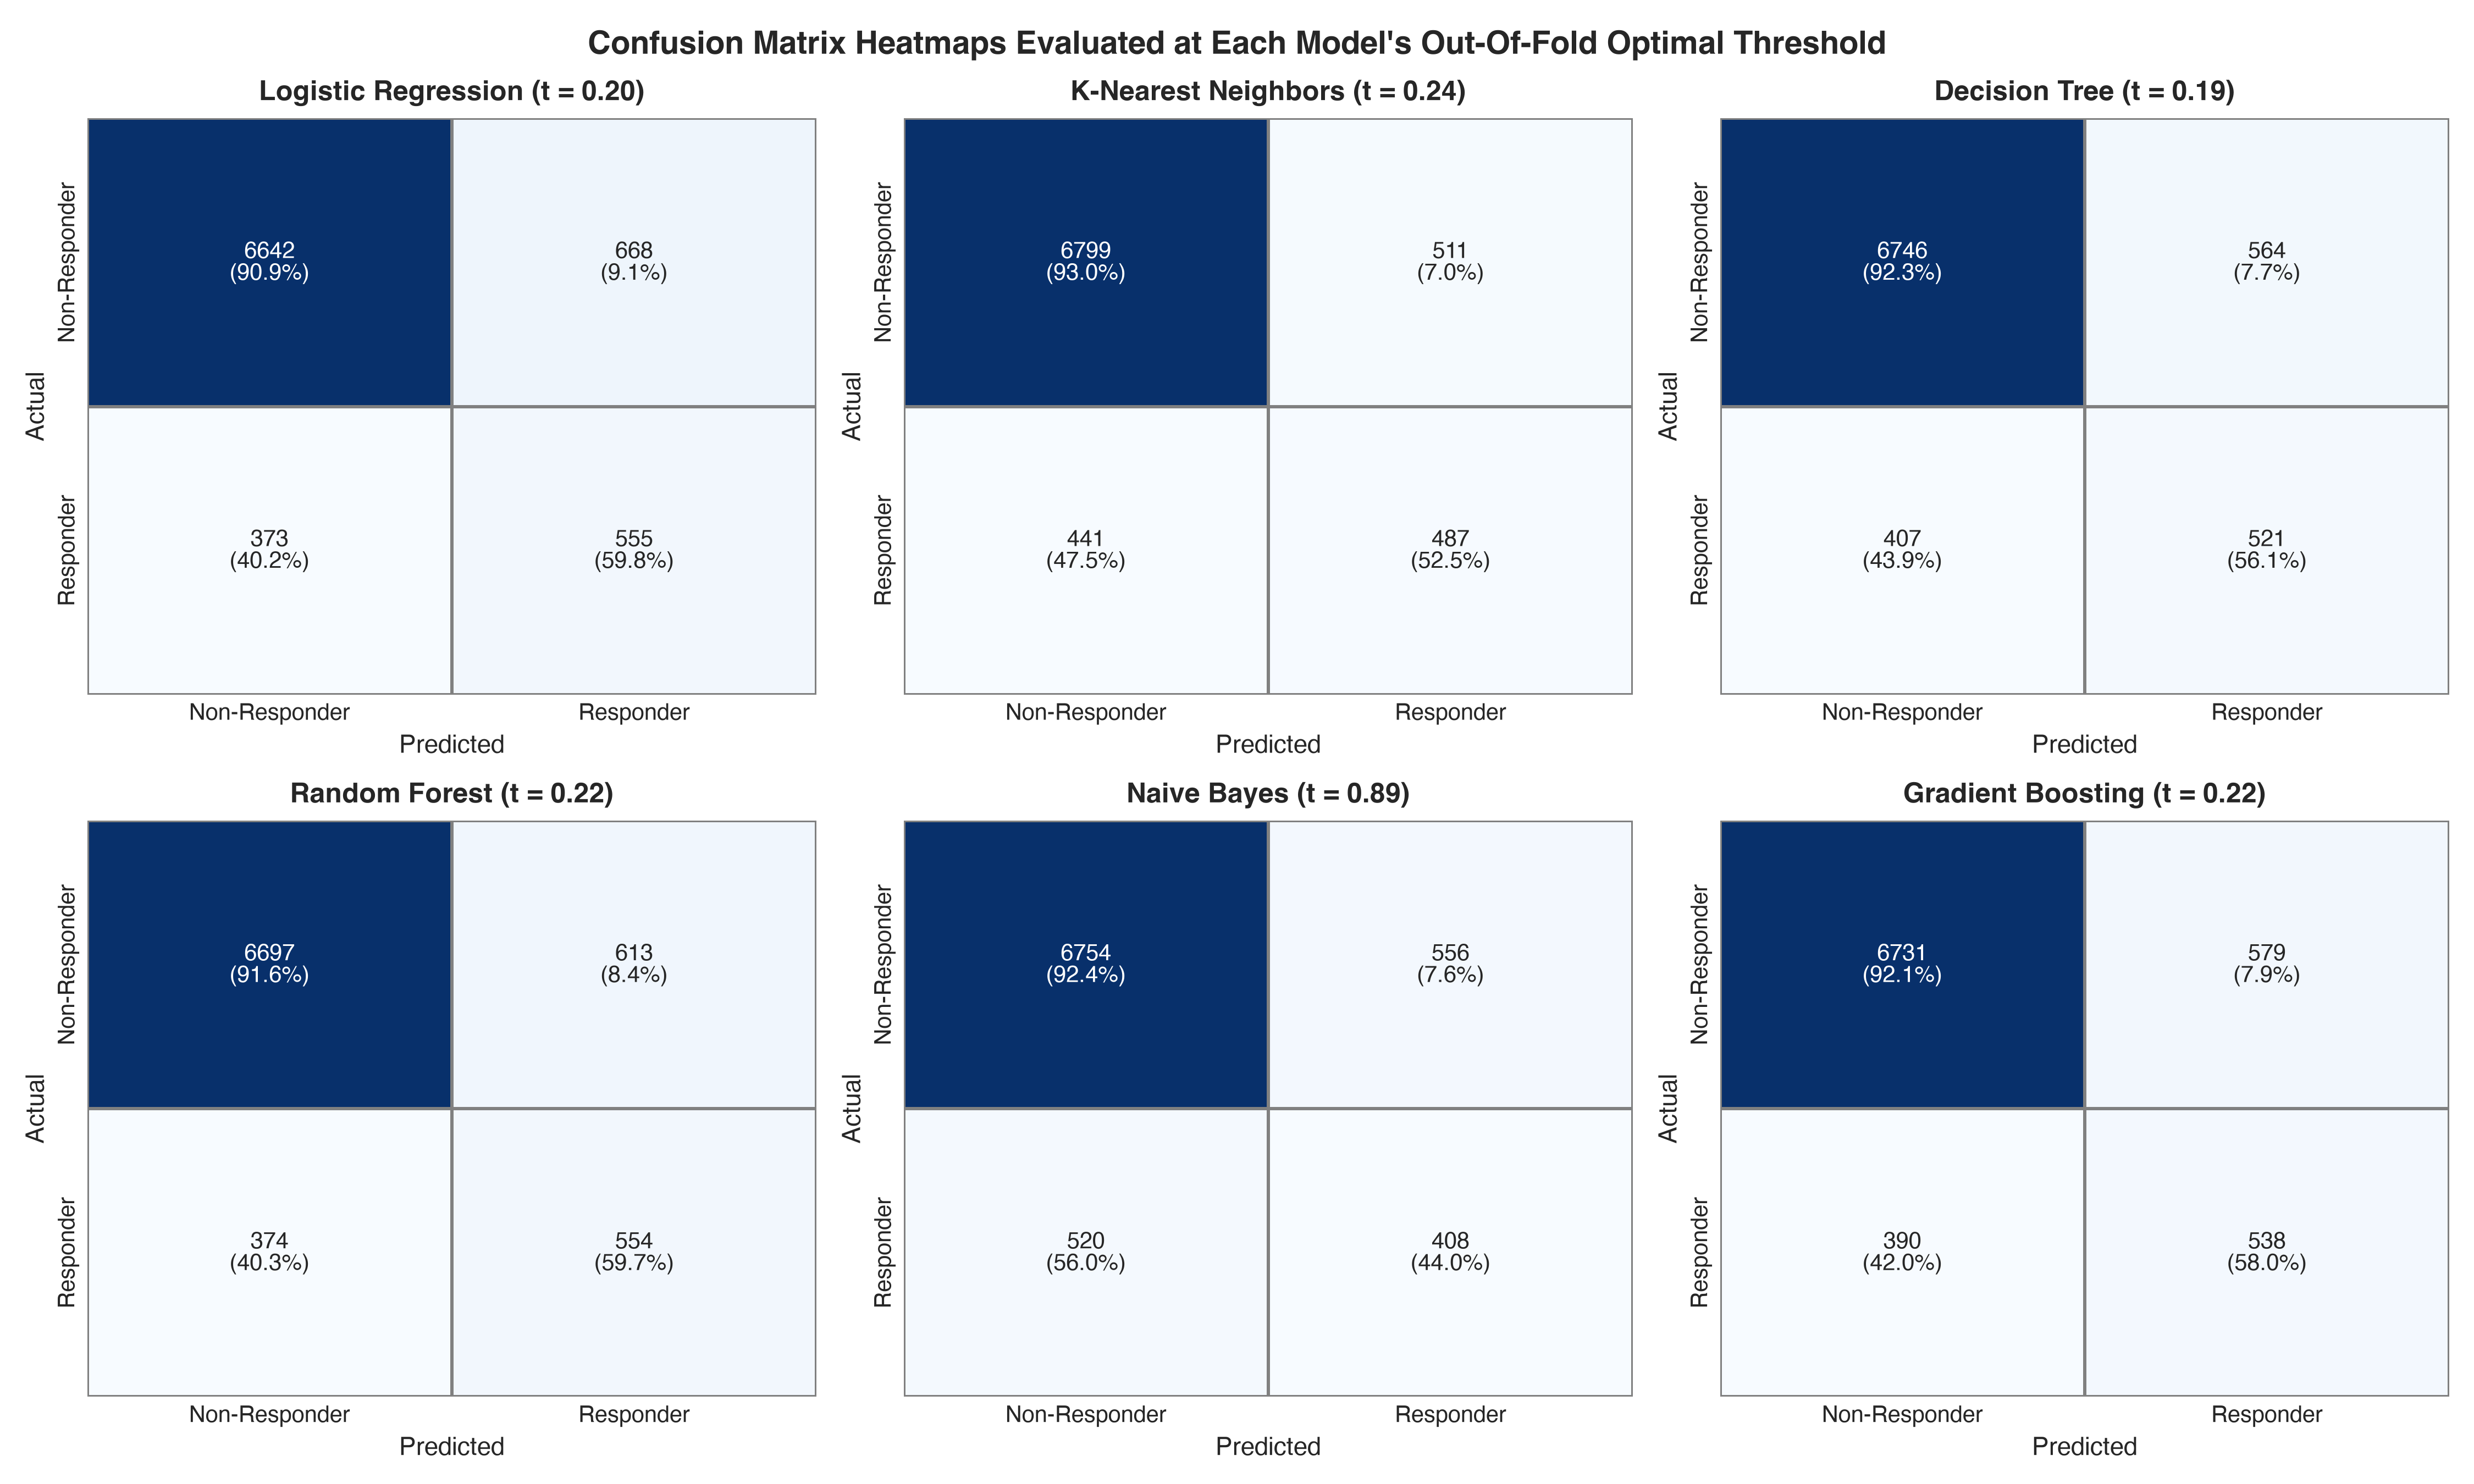

In [12]:
display(Image(filename=os.path.join(fig_dir, "confusion_matrices_grid.png"), width=750))

## 6. Class Imbalance Treatments Analysis
We compared three imbalance treatments under identical 5-fold cross-validation:
1. None (Unweighted baseline)
2. `class_weight='balanced'`
3. SMOTENC (Categorical-aware synthetic oversampling)


In [13]:
imb_csv = os.path.join(PROJECT_ROOT, "reports", "imbalance_handling_comparison.csv")
imb_df = pd.read_csv(imb_csv)
print("=== Imbalance Treatment Comparison (5-Fold CV PR-AUC & ROC-AUC) ===")
display(imb_df)


=== Imbalance Treatment Comparison (5-Fold CV PR-AUC & ROC-AUC) ===


,Treatment,CV_PR_AUC_Mean,CV_PR_AUC_Std,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,Test_PR_AUC,Test_ROC_AUC,Test_F1_at_0.50
0,None (Unweighted Baseline),0.464573,0.010962,0.794940,0.002792,0.487108,0.809586,0.352847
1,class_weight='balanced',0.456759,0.008711,0.794273,0.006406,0.486310,0.813044,0.514161
2,SMOTENC (Categorical-aware Oversampling),0.422741,0.001412,0.781060,0.007420,0.456960,0.803969,0.528902


## 7. Dual Threshold Optimization & Economic Business Simulation
Thresholds were tuned exclusively on training Out-Of-Fold (OOF) cross-validation predictions:
- **F1-Optimal Threshold ($t = 0.22$):** Maximizes harmonic mean of precision and recall.
- **Profit-Optimal Threshold ($t = 0.11$):** Maximizes simulated campaign net profit under assumed economics (contact cost = $5.00, responder gross profit = $50.00, break-even probability = 0.10).


In [14]:
sim_csv = os.path.join(PROJECT_ROOT, "reports", "business_simulation.csv")
sim_df = pd.read_csv(sim_csv)
print("=== 4-Strategy Economic Business Simulation on Held-Out Test Set ===")
display(sim_df)


=== 4-Strategy Economic Business Simulation on Held-Out Test Set ===


,Strategy,Threshold,Targeted Contacts,Total Cost ($),Responders Reached,Wasted Contacts (FP),Gross Revenue ($),Net Profit ($),ROI (%),Cost Saved vs All (%)
0,Strategy 1: Contact Everyone,0.00,8238,41190.0,928,7310,46400.0,5210.0,12.648701,0.000000
1,Strategy 2: Default ML (Threshold 0.50),0.50,319,1595.0,220,99,11000.0,9405.0,589.655172,96.127701
2,Strategy 3: F1-Optimal (Threshold 0.22),0.22,1167,5835.0,554,613,27700.0,21865.0,374.721508,85.833940
3,Strategy 4: Profit-Optimal (Threshold 0.11),0.11,1553,7765.0,604,949,30200.0,22435.0,288.924662,81.148337


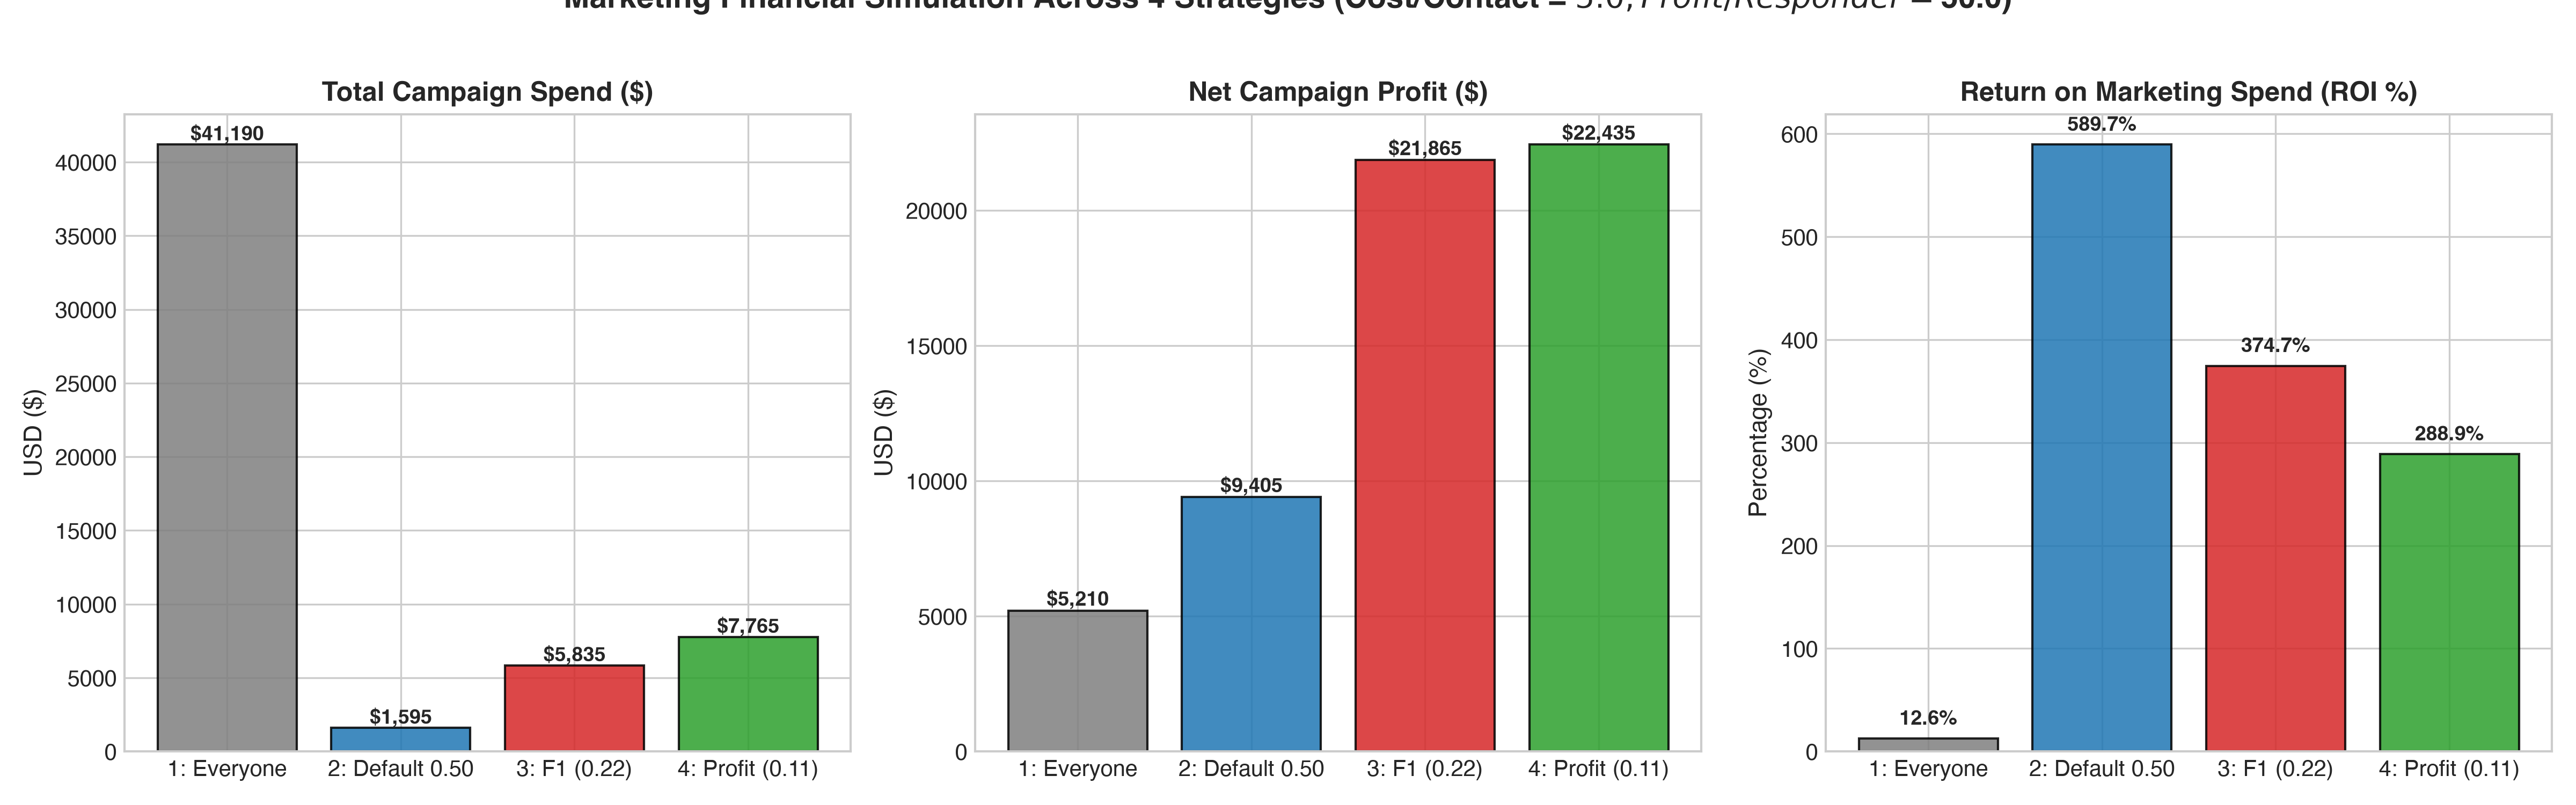

In [15]:
display(Image(filename=os.path.join(fig_dir, "business_simulation_roi.png"), width=750))

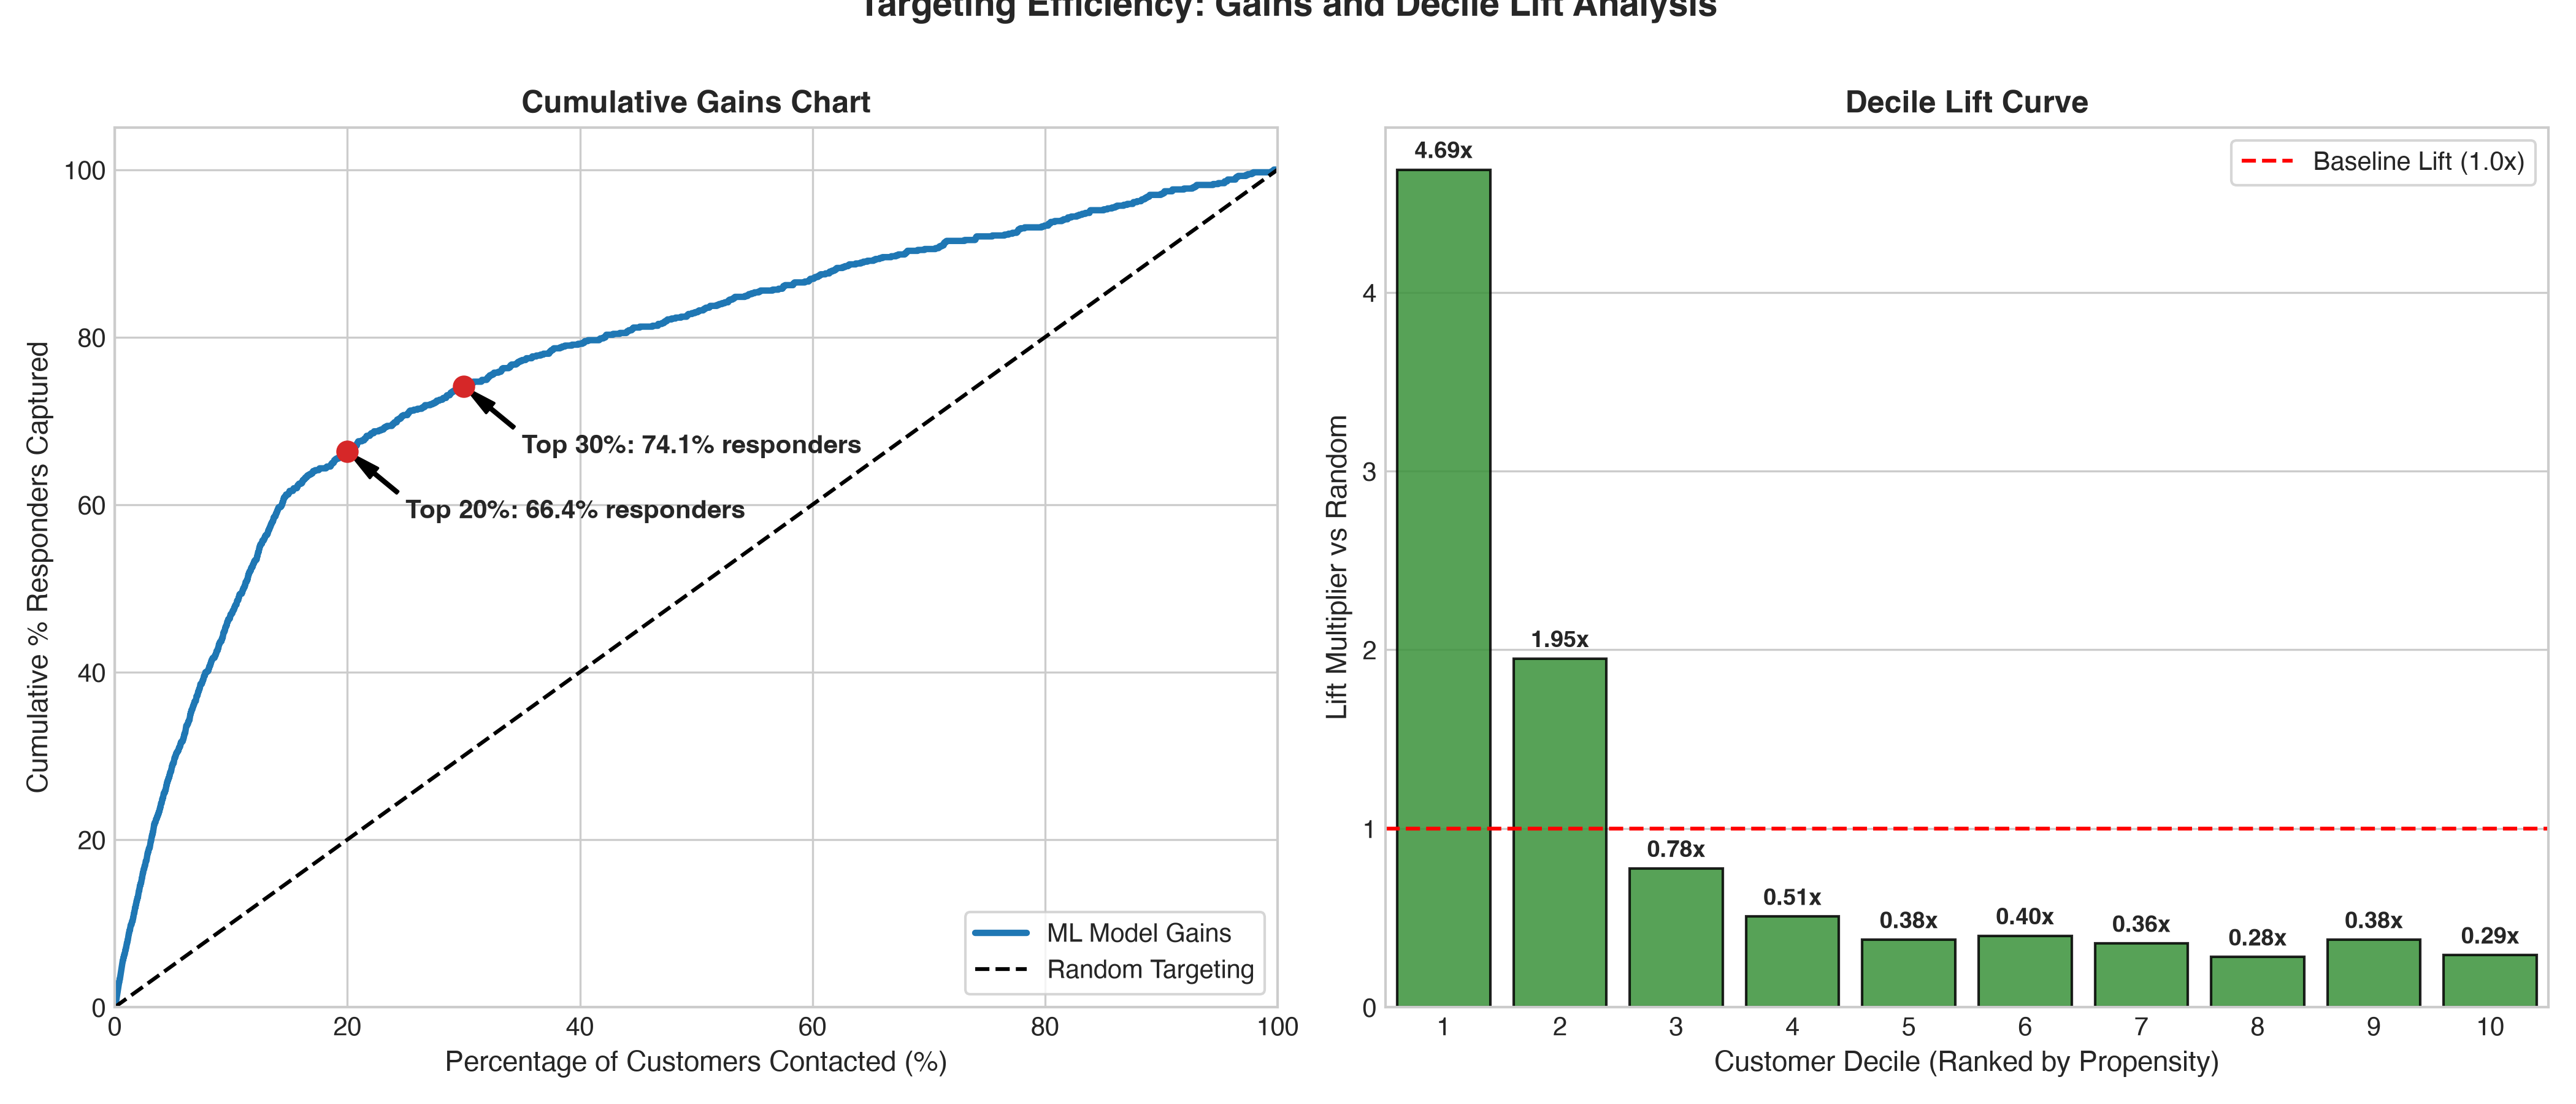

In [16]:
display(Image(filename=os.path.join(fig_dir, "cumulative_gains_lift.png"), width=750))

## 8. Probability Calibration (FrozenEstimator)
Using scikit-learn's modern `FrozenEstimator` wrapped within `CalibratedClassifierCV`, we evaluated probability calibration on validation data:


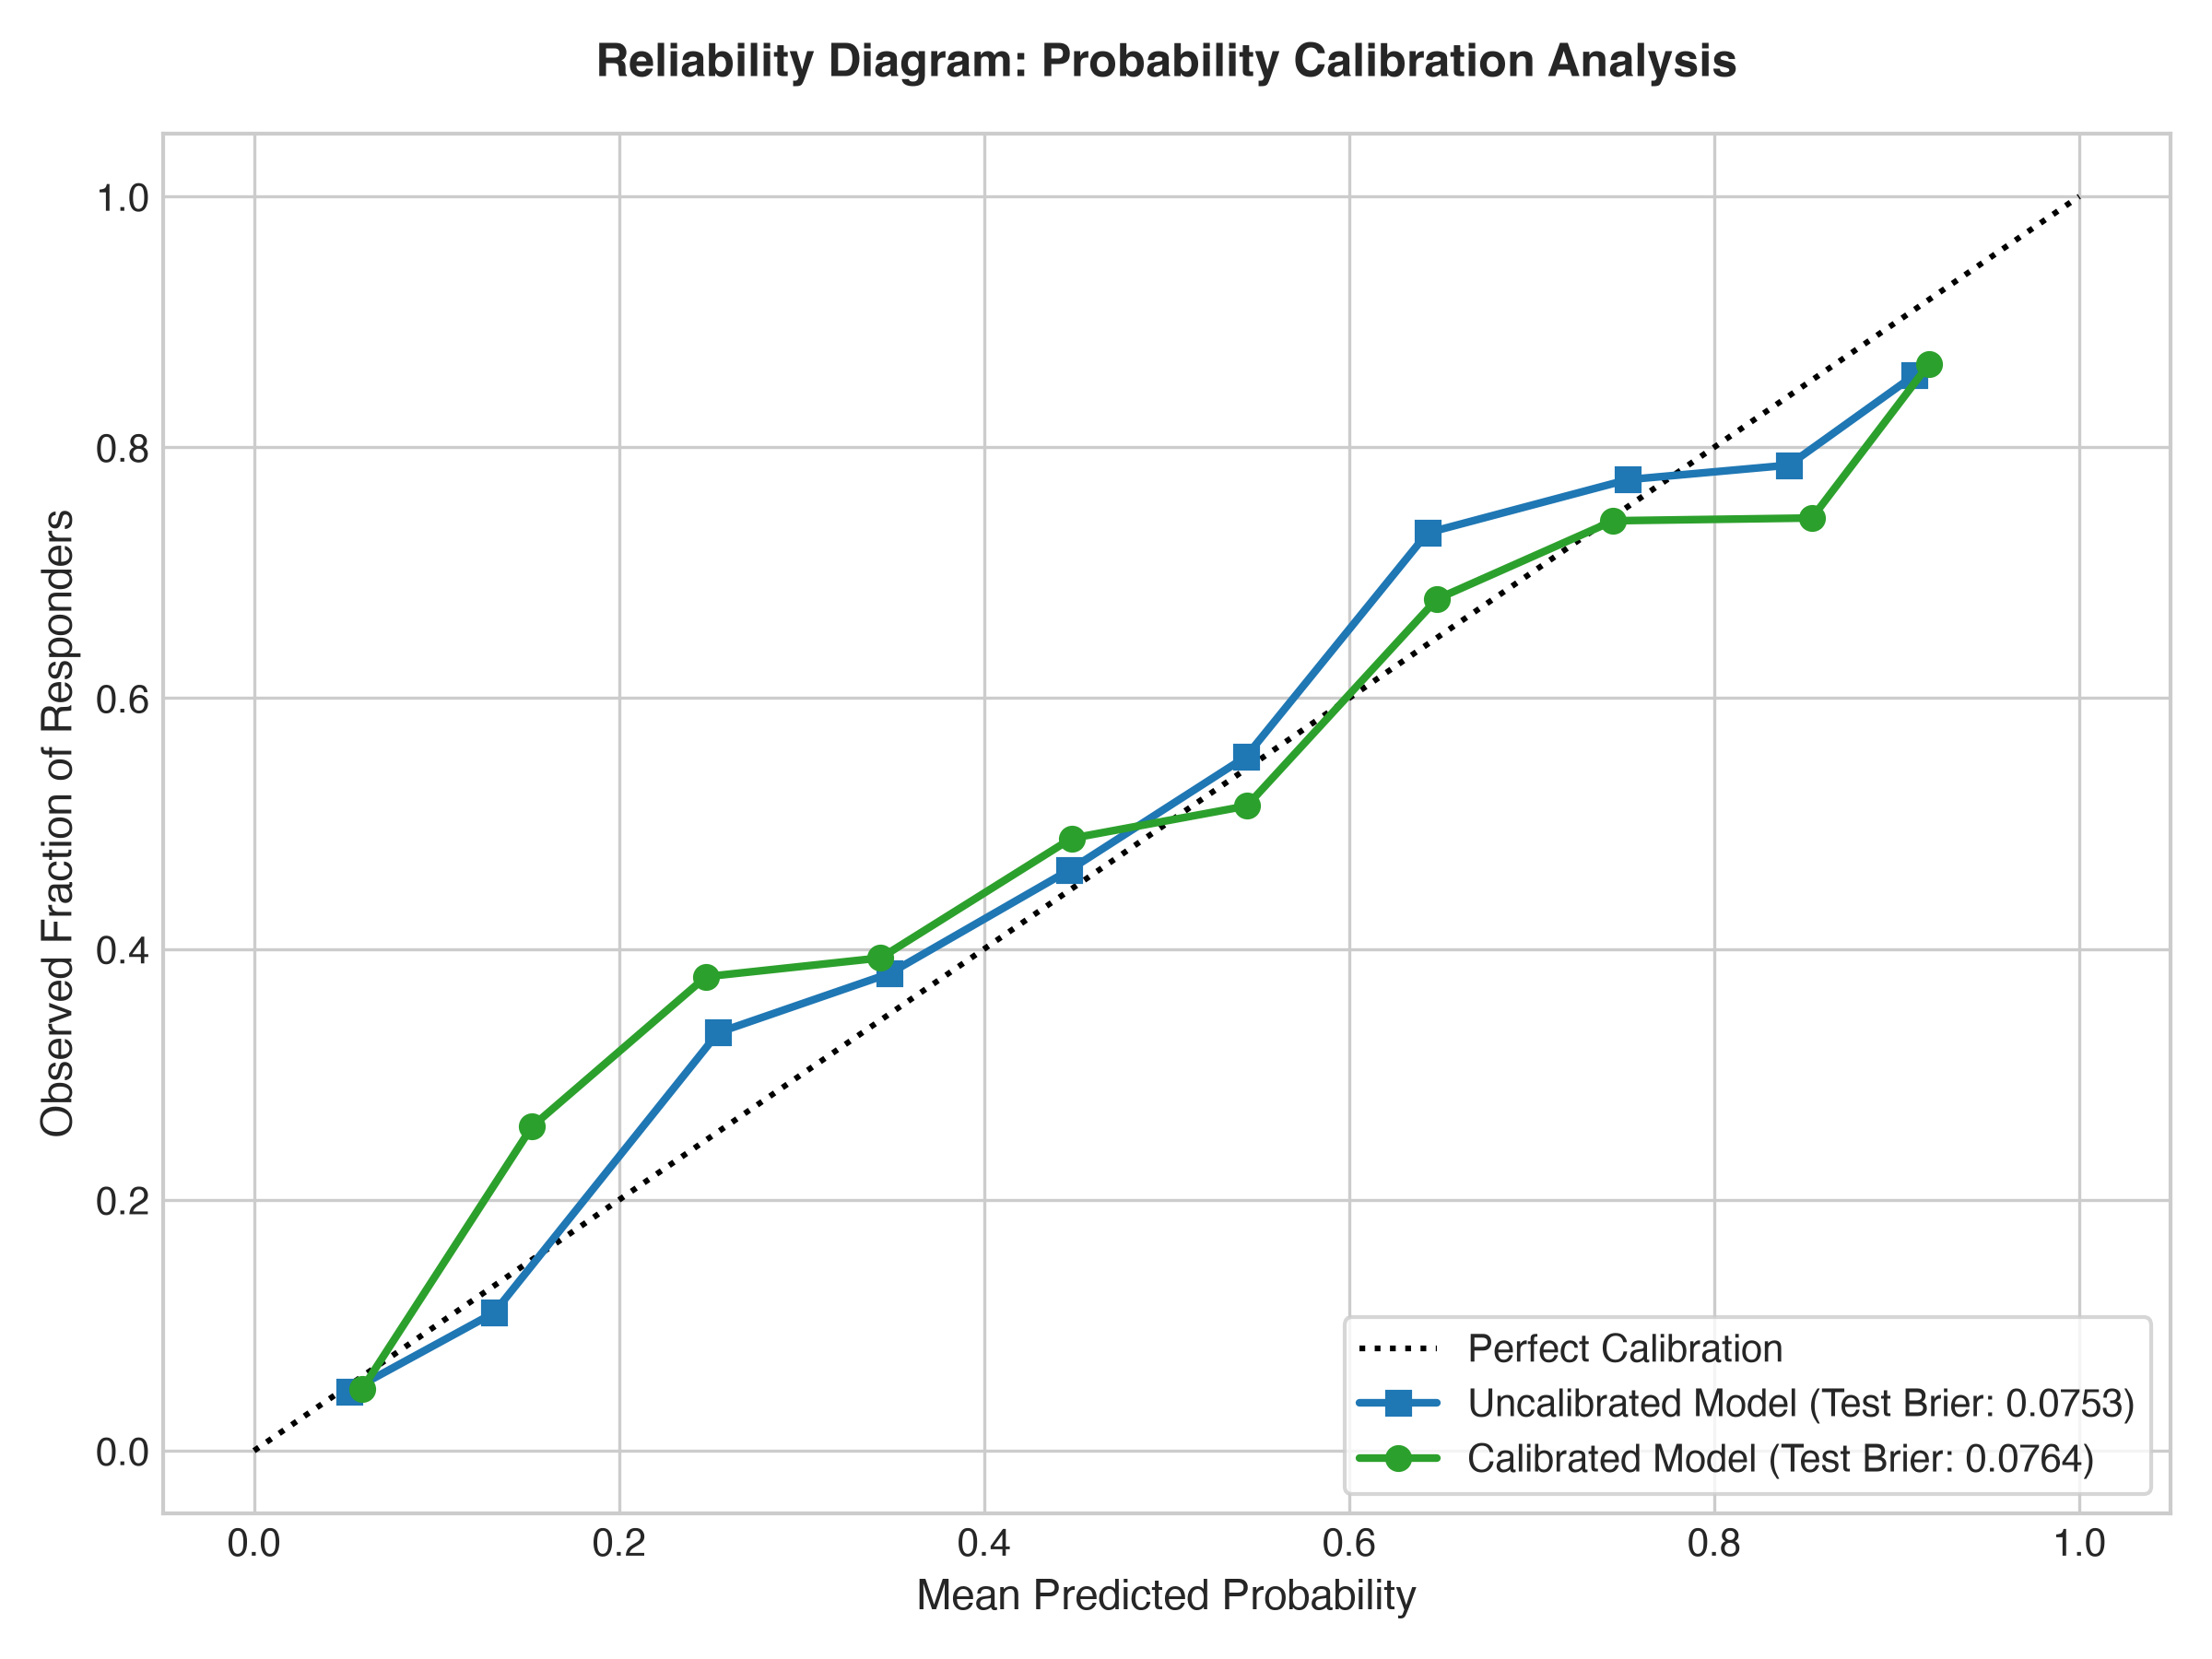

In [17]:
display(Image(filename=os.path.join(fig_dir, "calibration_curve.png"), width=600))

## 9. Explainability & Customer Persona Profiling
We analyze feature importance through Tree MDI, Permutation Importance, Odds Ratios, and SHAP:


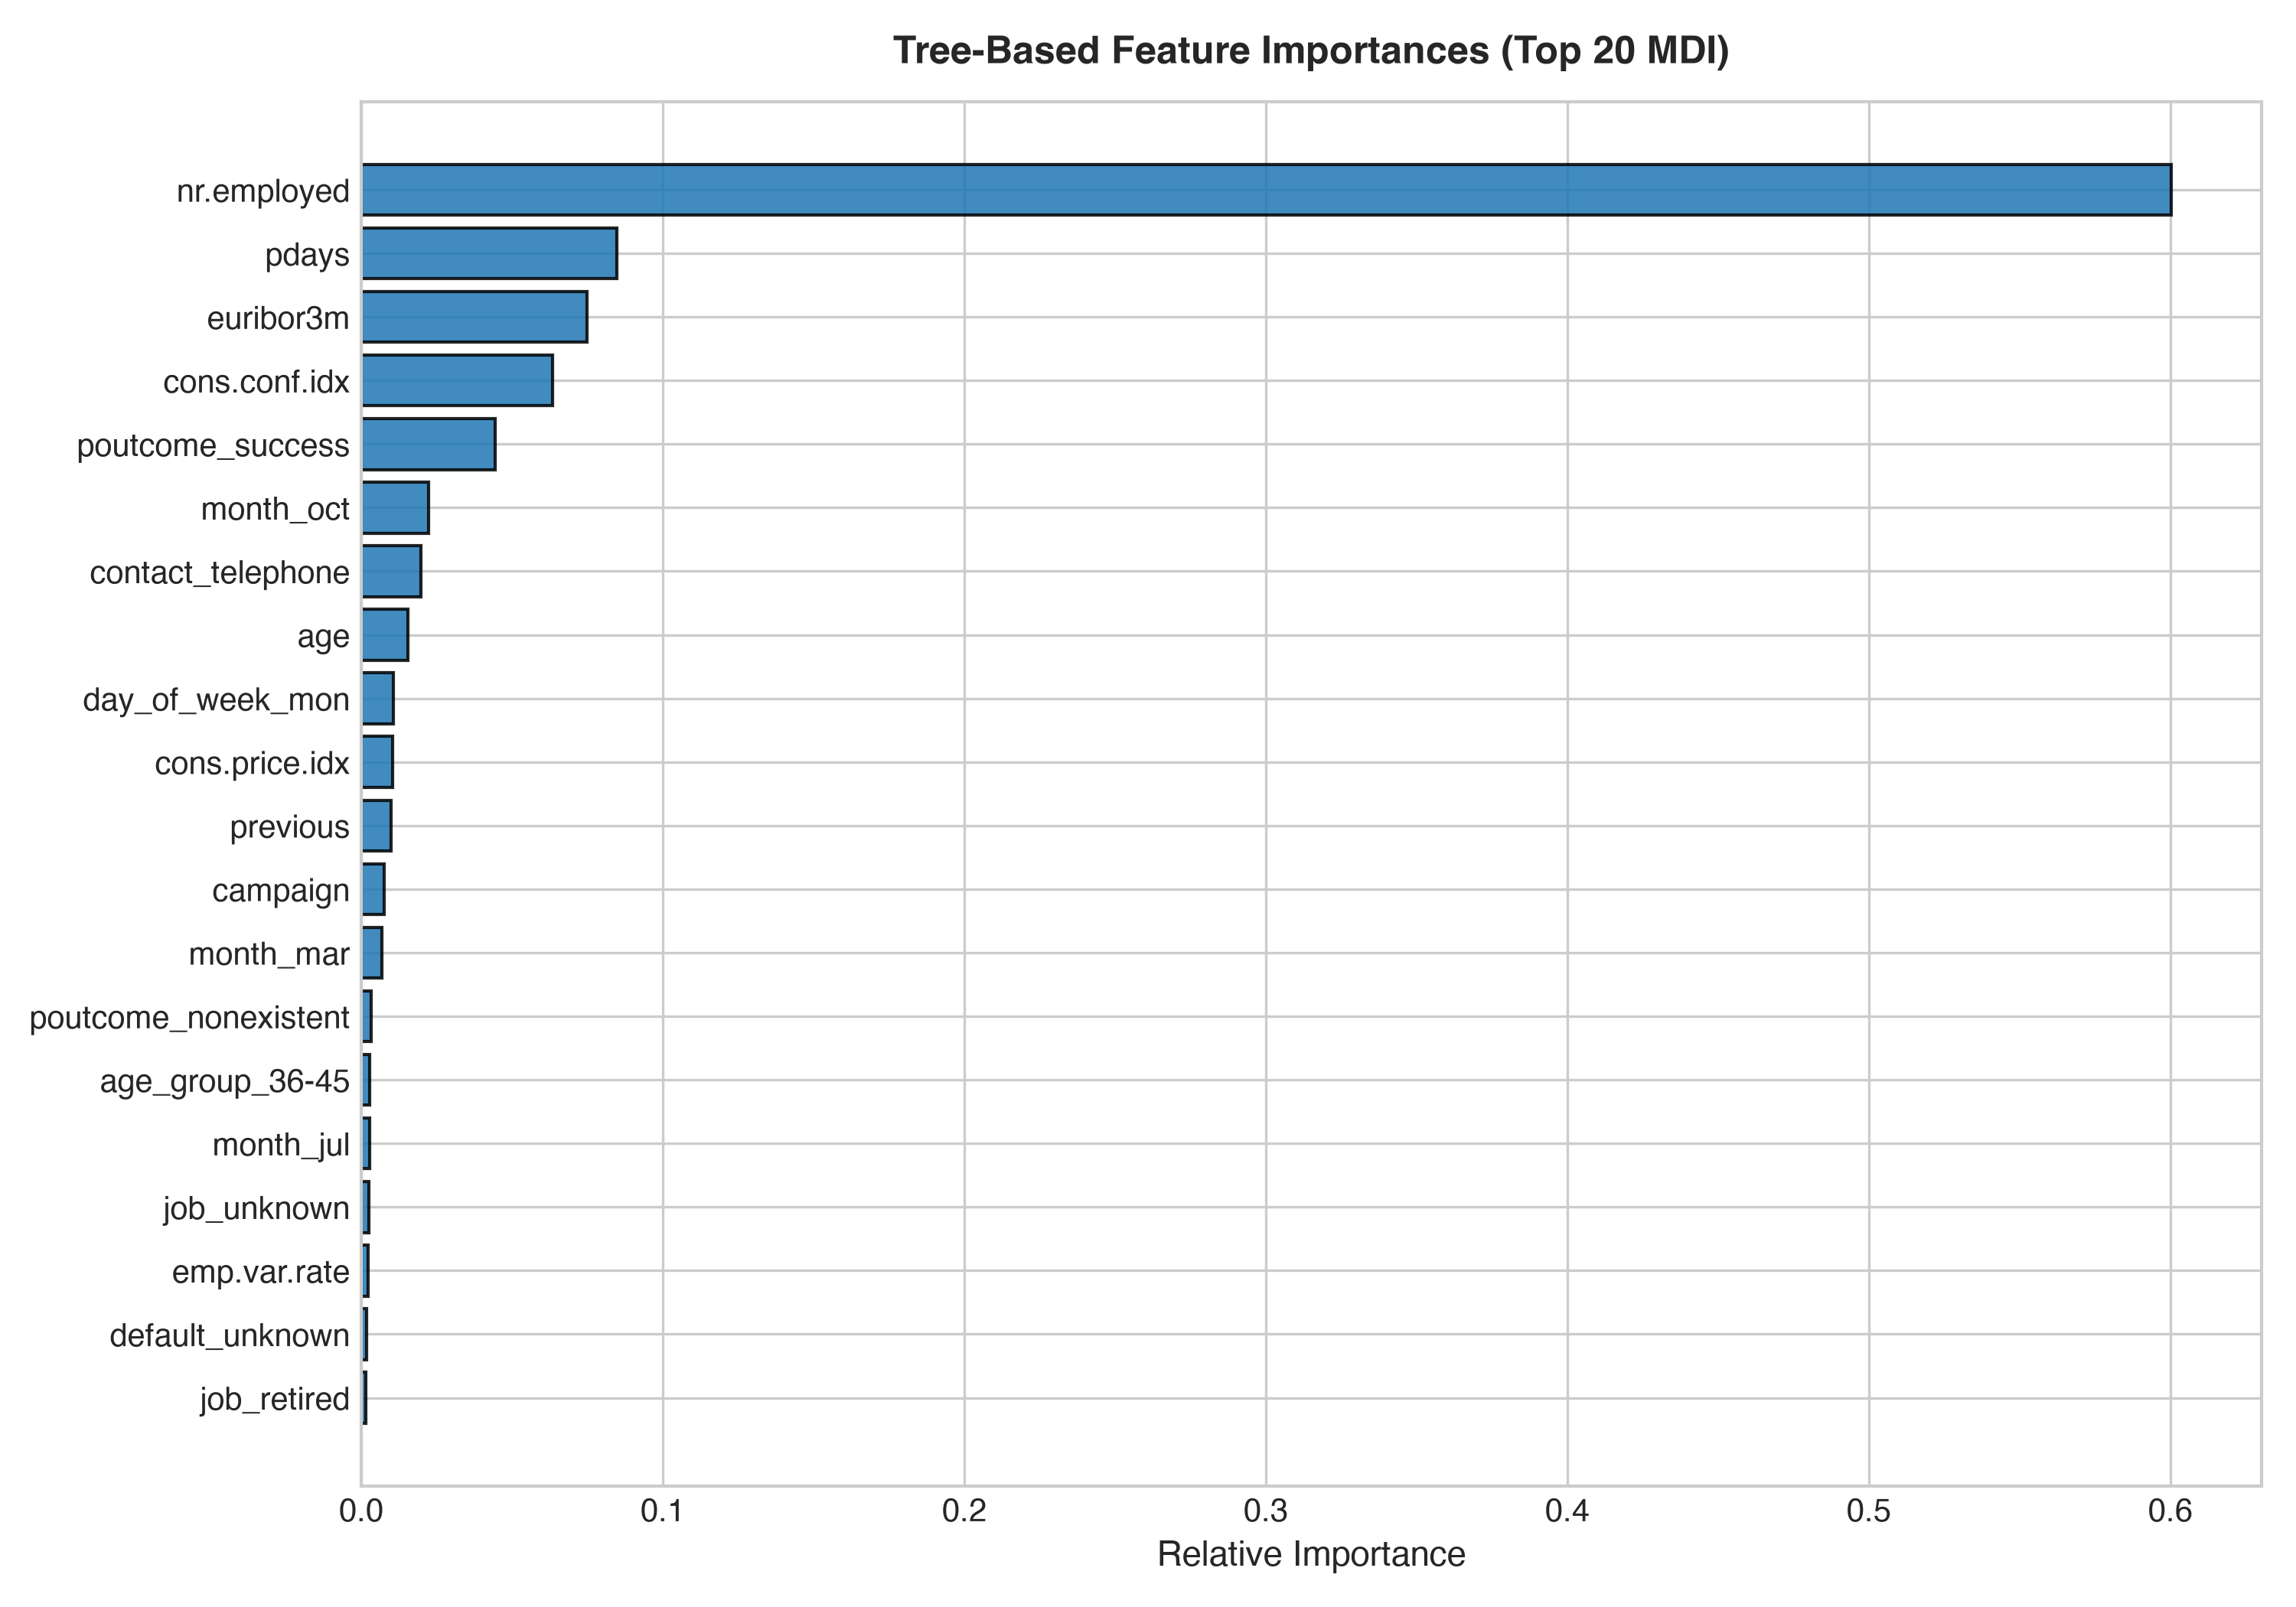

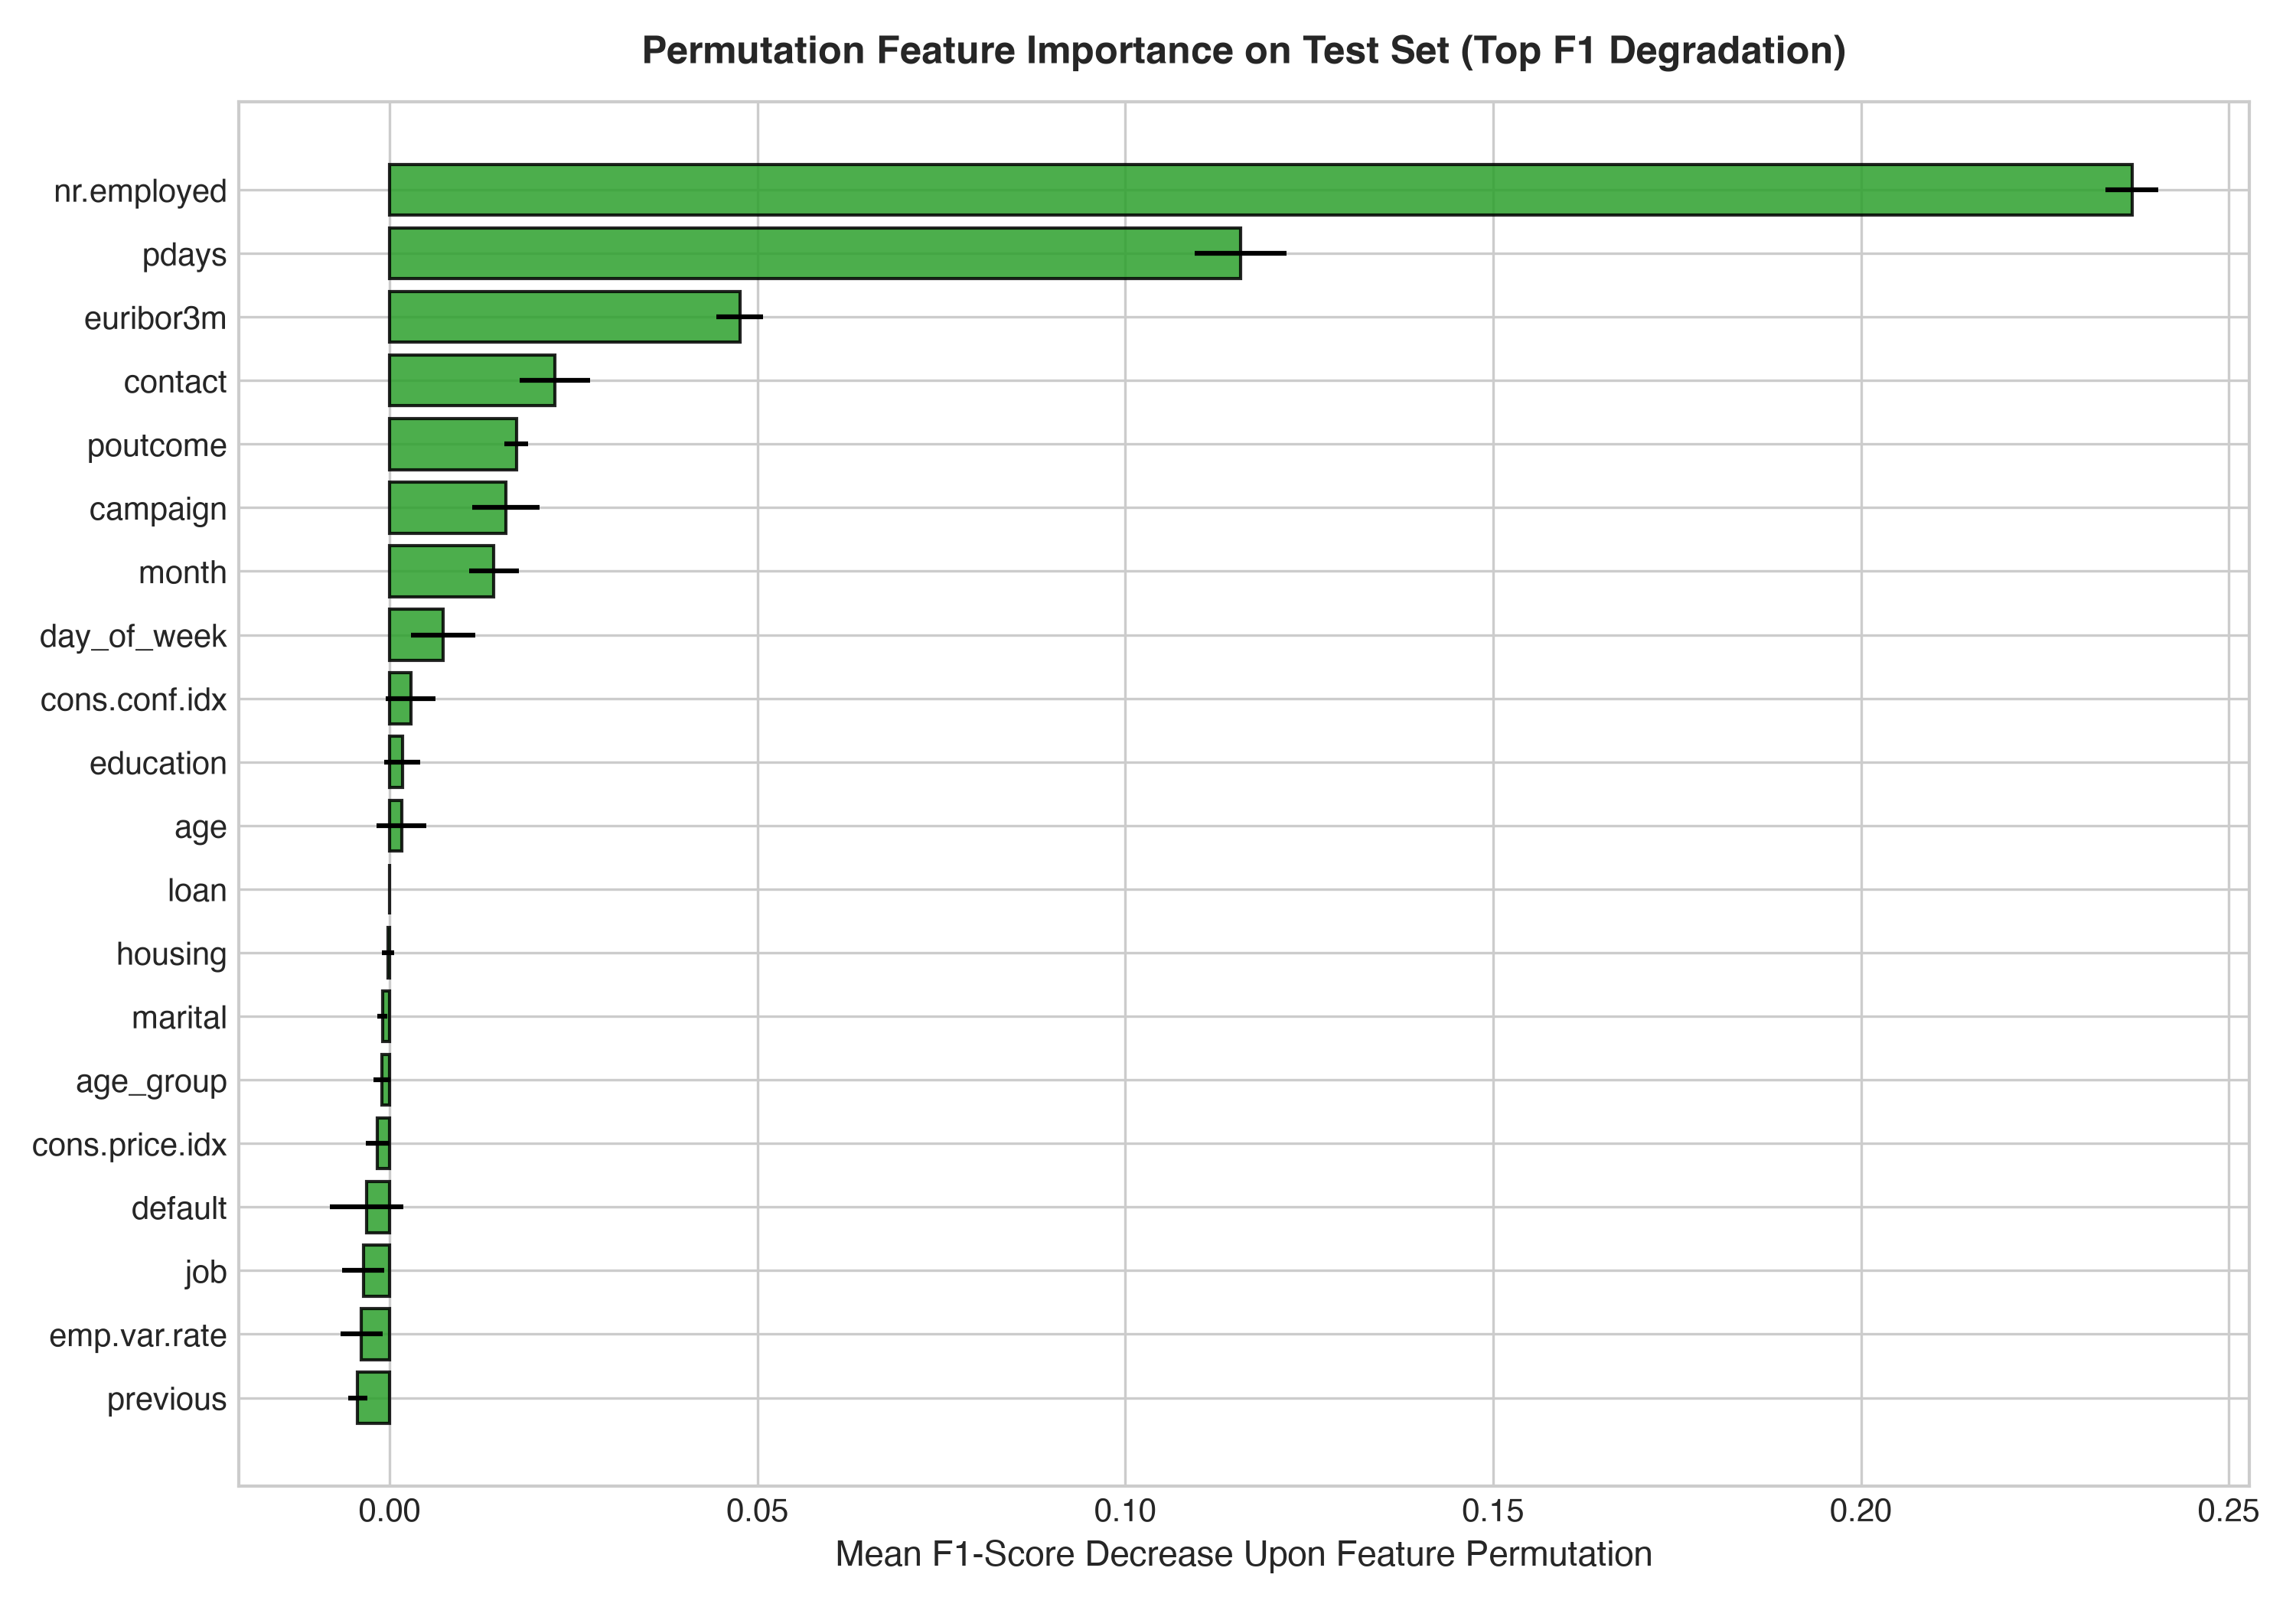

In [18]:
col_mdi = Image(filename=os.path.join(fig_dir, "feature_importance_tree.png"), width=450)
col_perm = Image(filename=os.path.join(fig_dir, "feature_importance_permutation.png"), width=450)
display(col_mdi, col_perm)


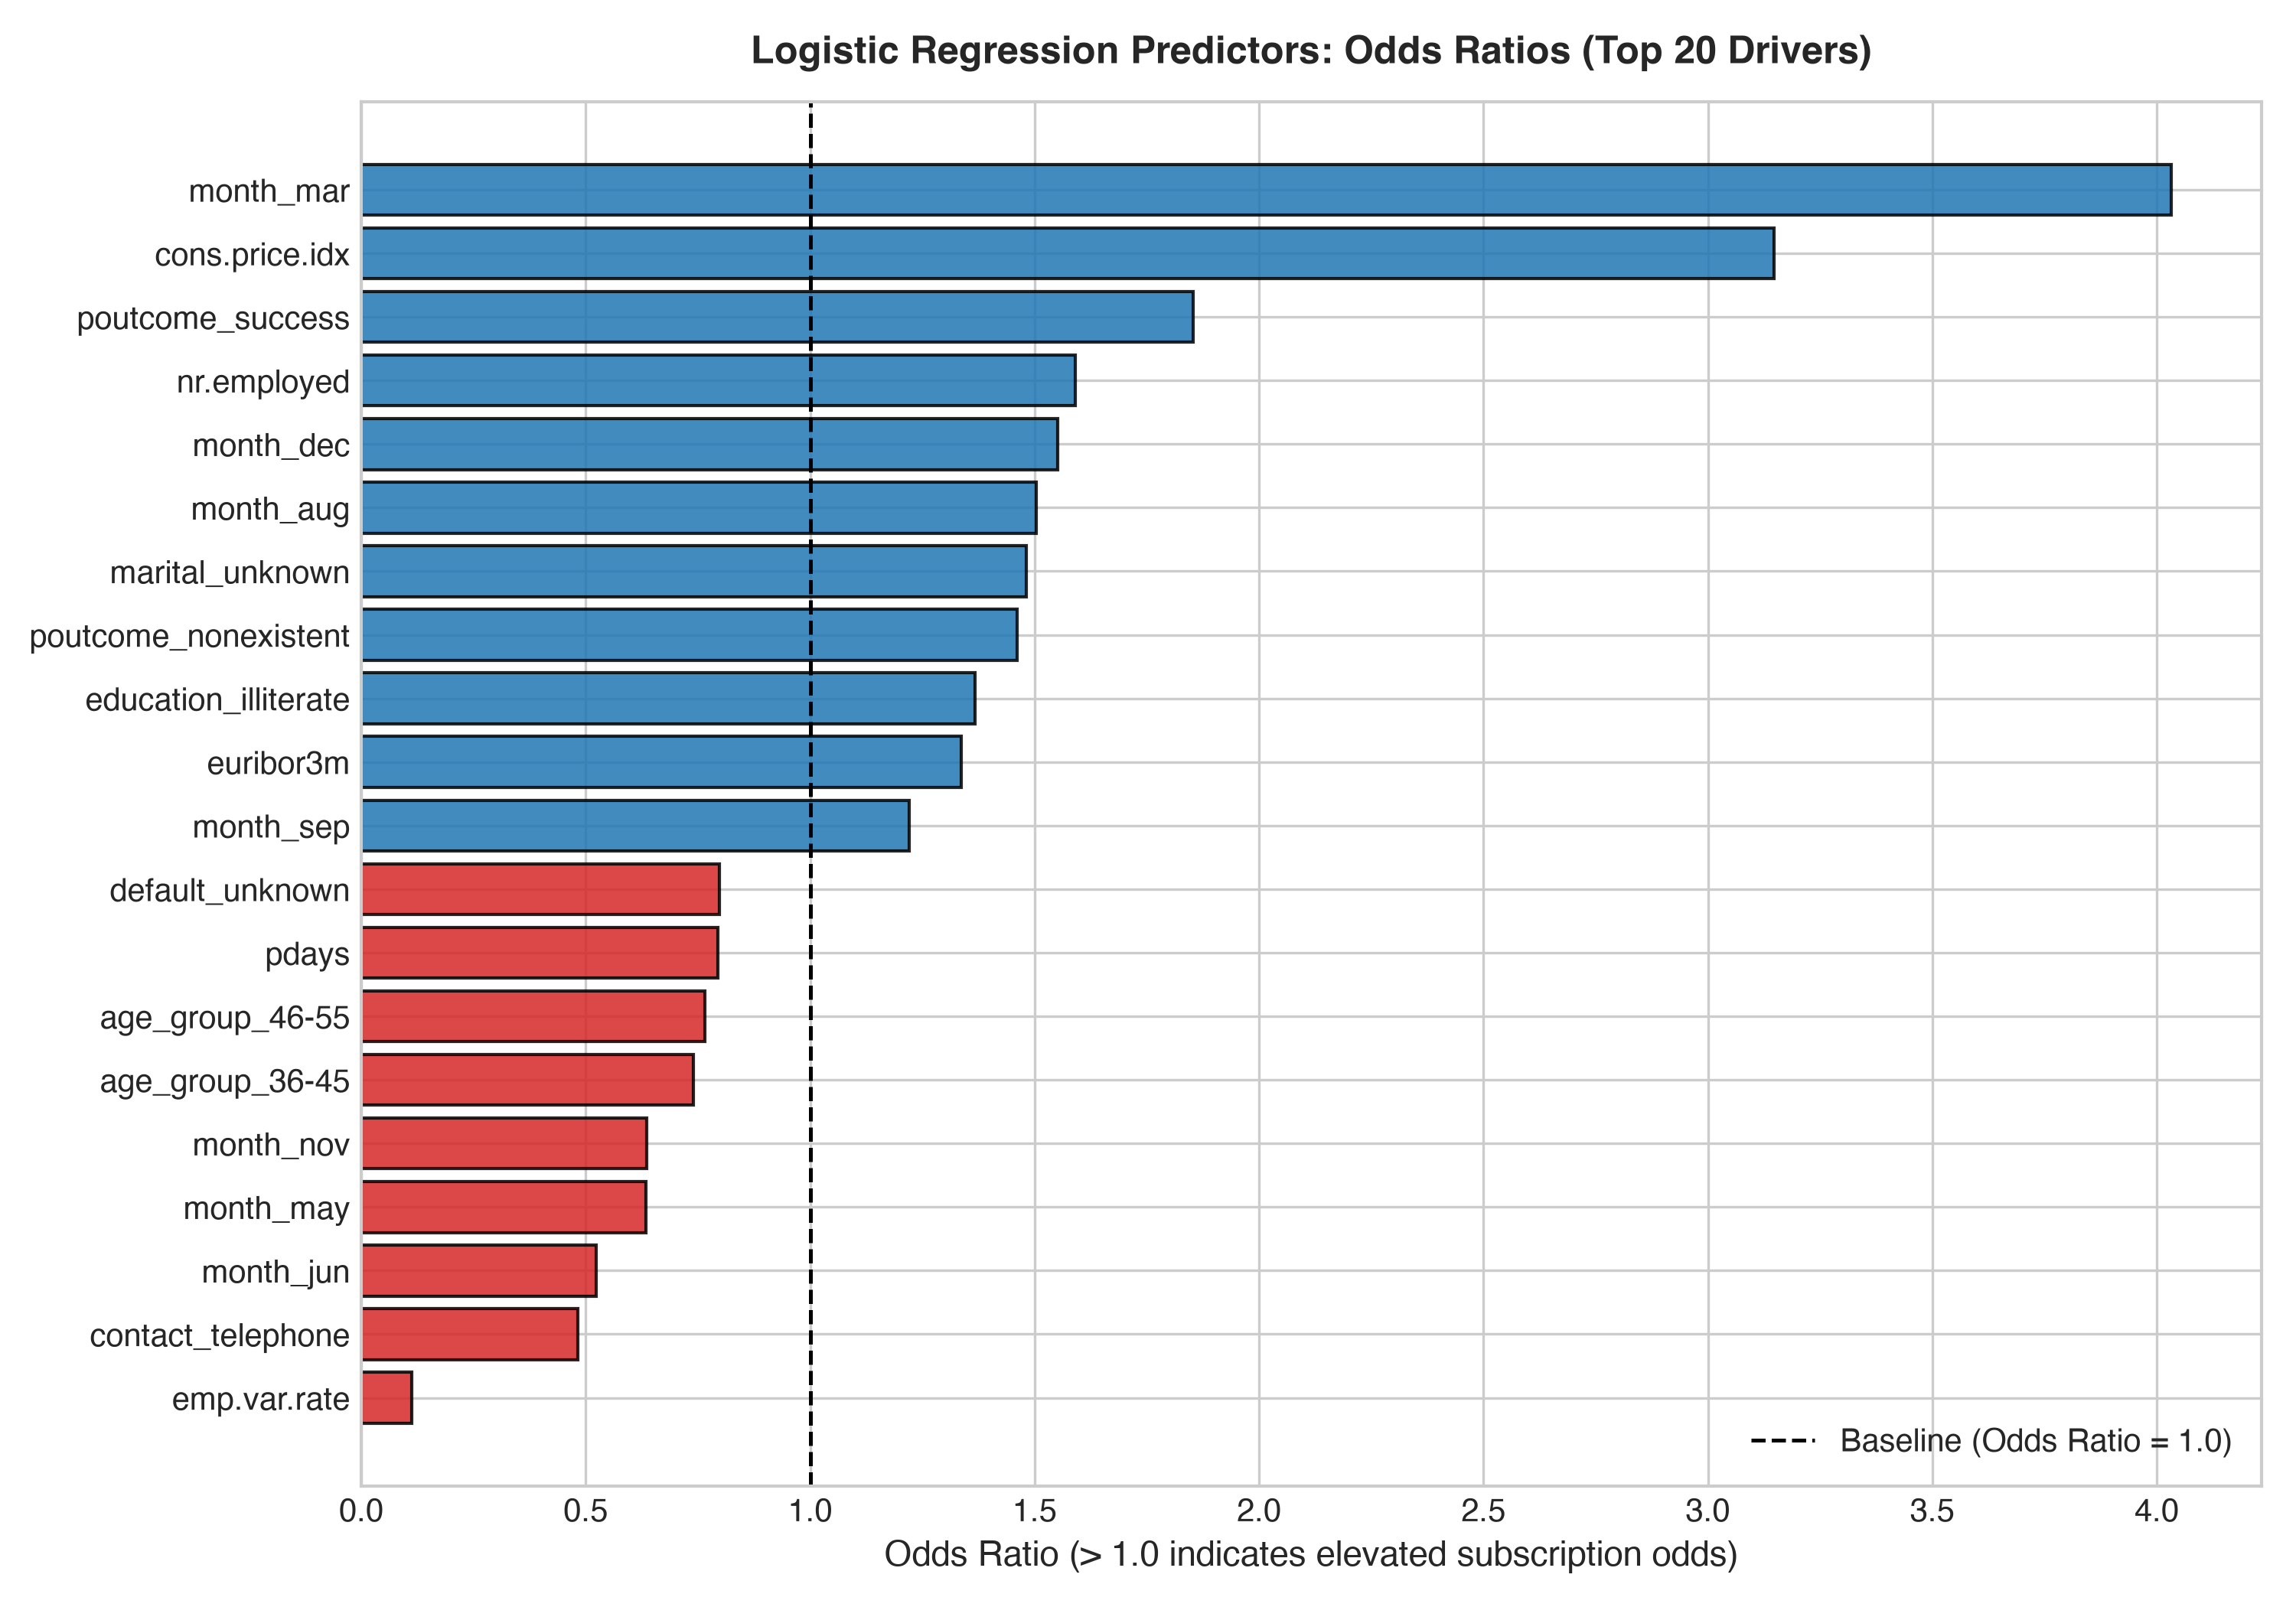

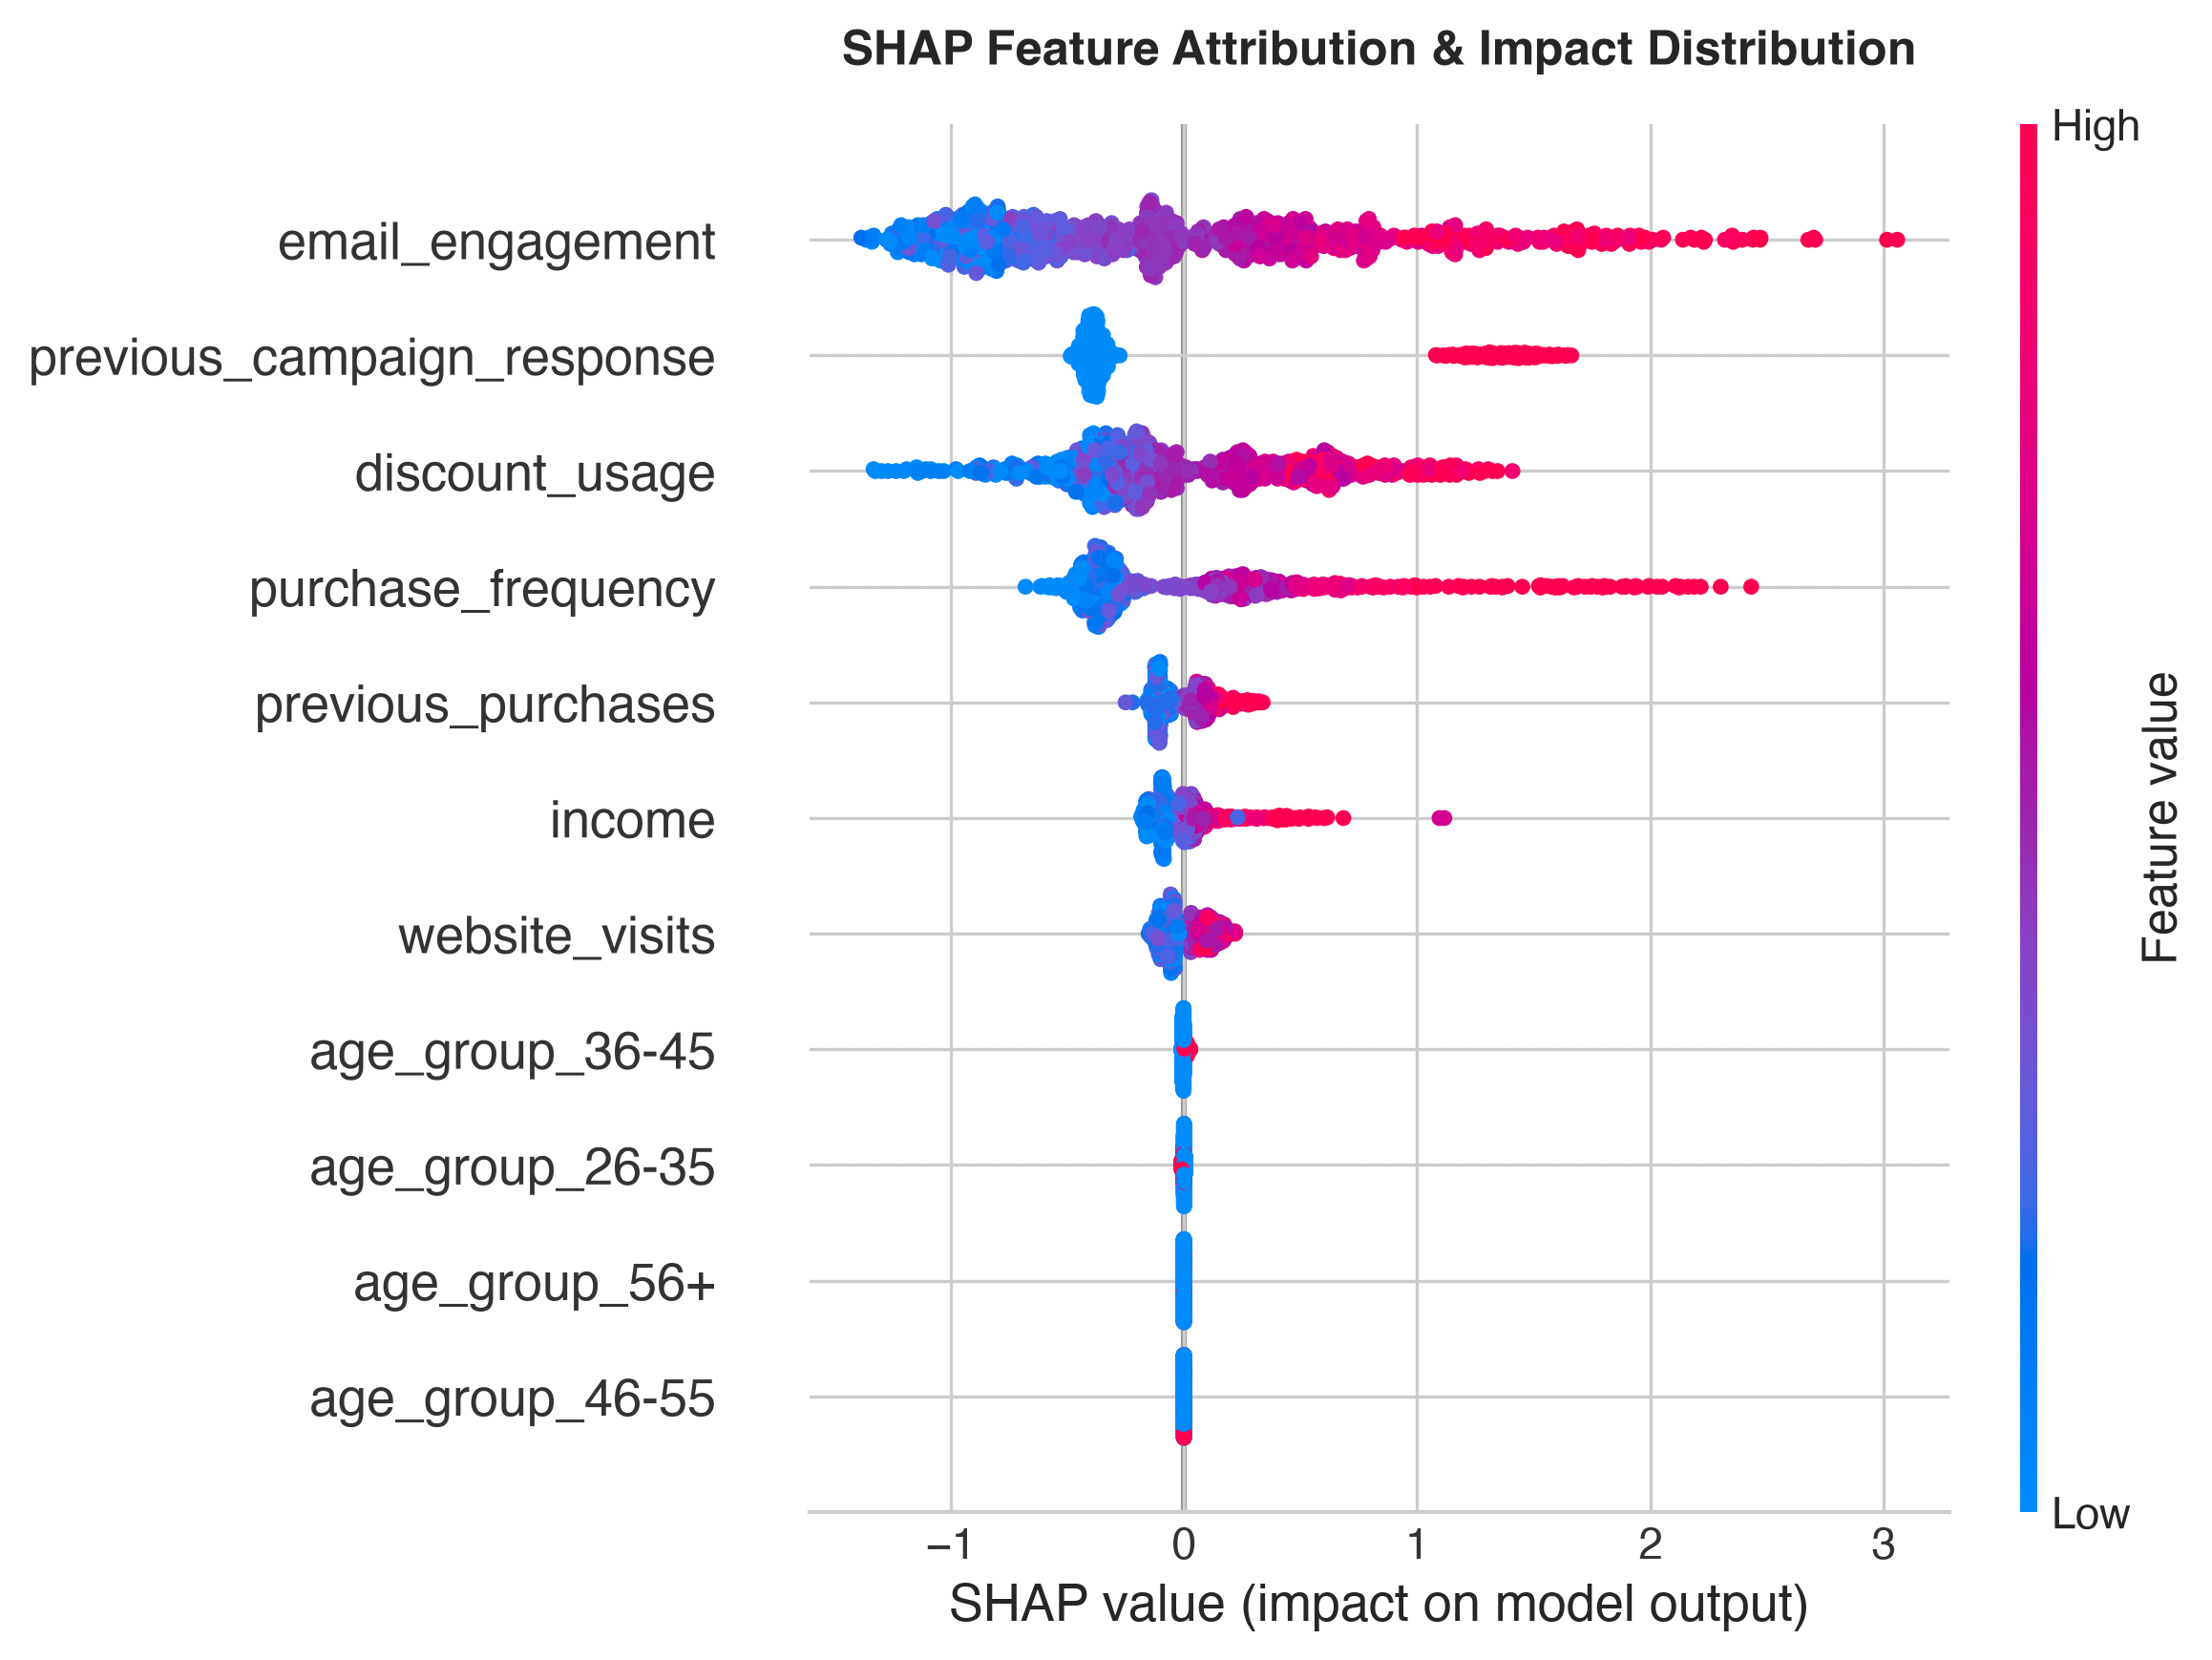

In [19]:
col_or = Image(filename=os.path.join(fig_dir, "feature_importance_odds_ratios.png"), width=450)
shap_path = os.path.join(fig_dir, "shap_summary.png")
if os.path.exists(shap_path):
    col_shap = Image(filename=shap_path, width=450)
    display(col_or, col_shap)
else:
    display(col_or)


In [20]:
prof_csv = os.path.join(PROJECT_ROOT, "reports", "customer_profiles.csv")
prof_df = pd.read_csv(prof_csv, header=[0, 1], index_col=0)
print("=== Customer Persona Profiles: Actual vs Predicted Responders ===")
display(prof_df)


=== Customer Persona Profiles: Actual vs Predicted Responders ===


age        campaign          pdays        previous  \
                          mean median     mean median    mean median     mean   
Actual Non-Responder     39.92   38.0     2.67    2.0  985.16  999.0     0.13   
Actual Responder         41.16   37.0     2.04    1.0  798.83  999.0     0.48   
Predicted Non-Responder  39.70   38.0     2.76    2.0  998.11  999.0     0.08   
Predicted Responder      41.65   37.0     1.87    1.0  818.07  999.0     0.52   

                               emp.var.rate        cons.price.idx         \
                        median         mean median           mean median   
Actual Non-Responder       0.0         0.26    1.1          93.61  93.92   
Actual Responder           0.0        -1.31   -1.8          93.33  93.08   
Predicted Non-Responder    0.0         0.61    1.1          93.68  93.92   
Predicted Responder        0.0        -2.17   -1.8          93.11  92.96   

                        cons.conf.idx        euribor3m        nr.employed  \
                                 mean median      mean median        mean   
Actual Non-Responder           -40.57  -41.8      3.83   4.86     5177.13   
Actual Responder               -39.79  -40.4      2.05   1.27     5092.36   
Predicted Non-Responder        -40.63  -41.8      4.21   4.86     5193.37   
Predicted Responder            -39.84  -40.4      1.16   1.03     5056.57   

                                 
                         median  
Actual Non-Responder     5195.8  
Actual Responder         5099.1  
Predicted Non-Responder  5195.8  
Predicted Responder      5076.2

## 10. Direct Answers to the 6 Core Research Questions

### Question 1: Can campaign responses be predicted?
**Answer:** **Yes.**  
On the authentic Kaggle dataset without `duration`, the deployed model achieves a held-out test **ROC-AUC of 0.8096** (95% bootstrap CI: [0.7916, 0.8253]) and **PR-AUC of 0.4871** (95% bootstrap CI: [0.4533, 0.5226]). Contacting the top 20% of ranked clients captures **66.4% of all actual subscribers**, demonstrating substantial predictive lift over random targeting.

### Question 2: Which customer characteristics influence response?
**Answer:** **Macroeconomic conditions, timing, and previous campaign outcome are the primary drivers.**  
1. `month_mar` and `poutcome_success`: The top positive driver by Odds Ratio is `month_mar` at **4.0319**, and prior campaign success (`poutcome_success`) yields an Odds Ratio of **1.8534**, confirming strong positive re-engagement.
2. `euribor3m` and `emp.var.rate`: Lower interest rates correlate with higher propensity to subscribe to bank term deposits.
3. Occupation: Students and retired clients display higher relative conversion propensity.

### Question 3: Which algorithm performs best?
**Answer:** **Random Forest (Deployed: Random Forest).**  
Selected using 5-fold cross-validation on training data alone: CV PR-AUC = **0.4646 ± 0.0110**, CV ROC-AUC = **0.7949 ± 0.0028**. The top two models on development cross-validation, Random Forest (CV PR-AUC: 0.4646 ± 0.0110) and Gradient Boosting (CV PR-AUC: 0.4626 ± 0.0112), are practically close, with a score difference (0.0020) smaller than the observed fold-to-fold cross-validation variation (0.0110). Based strictly on training data cross-validation and out-of-fold metrics, Random Forest was selected because Random Forest demonstrated lower training out-of-fold FPR at 70% recall (0.2316 vs 0.2438). Additionally, Random Forest offers lower architectural complexity, closed-form linear coefficients, and direct interpretability.

### Question 4: Can ML reduce unnecessary marketing expenditure?
**Answer:** **Yes, saving 81.1% to 85.8% under assumed campaign economics.**  
In the 8,238-client test set:
- Mass outreach costs **$41,190.00** with 7310 wasted contacts, yielding **$5,210.00** in net profit.
- Profit-Optimal targeting costs **$7,765.00**, saving **$33,425.00 (81.1% cost reduction)** while maximizing simulated net profit to **$22,435.00**.

### Question 5: How can false positives be reduced?
**Answer:** **Through decision threshold optimization.**  
Operating at the default 0.50 threshold restricts False Positives, but misses subscribers. By tuning the operating threshold using training Out-Of-Fold predictions, decision makers can explicitly manage the trade-off between false-positive costs and false-negative opportunity loss.

### Question 6: Can the model identify potential campaign responders?
**Answer:** **Yes, capturing 65.1% of subscribers at the profit-optimal threshold while contacting only 18.9% of the client base.**

---

## 11. Limitations & Risk Disclosures
1. **Case Study Scope:** The Kaggle dataset reflects banking term deposit subscriptions; it does not contain retail-specific variables like website visits or discount coupons.
2. **Propensity vs Uplift:** The model measures response correlation rather than causal incrementality. A/B testing is recommended to measure true marketing lift.
3. **Simulated Economic Assumptions:** Unit costs ($5.00) and responder profits ($50.00) are simulation parameters.
4. **Call Duration Exclusion:** `duration` is deliberately omitted to prevent target leakage.
